# StyleGAN2-ADA: Synthetic Brain Tumor MRI Generation
## BRISC 2025 Dataset | Per-Plane Training Strategy

---

### Abstract

This notebook implements **StyleGAN2-ADA** (Adaptive Discriminator Augmentation) for generating photorealistic synthetic brain tumor MRI scans from the BRISC 2025 dataset. The approach addresses the fundamental challenge of training generative adversarial networks on limited medical imaging data (~300-500 images per class-plane combination).

### Methodology

**Per-Plane Training Strategy**: Rather than training a single model on mixed anatomical planes, we train 12 separate models (4 tumor classes x 3 anatomical planes). This approach:
- Preserves plane-specific morphological characteristics
- Reduces intra-class variance for more stable GAN training
- Enables plane-appropriate data augmentation strategies

**Adaptive Discriminator Augmentation (ADA)**: Dynamically adjusts augmentation probability based on discriminator overfitting signals, critical for small datasets where traditional GANs suffer mode collapse.

### Key Parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Resolution | 128x128 | Balances detail retention with computational efficiency |
| Architecture | StyleGAN2 | Proven stability for medical imaging |
| Augmentation | `bcf` | Color transforms only; geometric/cutout disabled |
| R1 Regularization (gamma) | 2.0 | Scaled for 128^2 resolution |
| ADA Target | 0.6 | Discriminator overfitting threshold |

---


In [1]:
# =============================================================================
# CELL 1: ENVIRONMENT SETUP + SILENCE WARNINGS
# =============================================================================
import os
import sys
import warnings

# Suppress all warnings (especially CUDA kernel compilation warnings)
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF warnings if any

# Set shorter path for PyTorch CUDA extensions (avoids Windows path length issues)
os.environ['TORCH_EXTENSIONS_DIR'] = 'C:/tmp/torch_ext'

# Suppress PyTorch specific warnings
import logging
logging.getLogger('torch').setLevel(logging.ERROR)
logging.getLogger('pytorch').setLevel(logging.ERROR)

print("="*70)
print("StyleGAN2-ADA BRAIN TUMOR MRI SYNTHESIS")
print("="*70)

# Get the project root
PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, '.')
print(f"\nWorking directory: {os.getcwd()}")

StyleGAN2-ADA BRAIN TUMOR MRI SYNTHESIS

Working directory: c:\Users\norie\Desktop\RA1


In [2]:
# =============================================================================
# CELL 2: INSTALL DEPENDENCIES
# =============================================================================
print("\n" + "="*70)
print("INSTALLING DEPENDENCIES")
print("="*70)

# Core dependencies (PyTorch, torchvision, scikit-image, etc.)
!pip install click requests tqdm pyspng ninja imageio-ffmpeg==0.4.3 pillow numpy matplotlib scipy

# Additional dependencies for advanced MRI preprocessing (Rician noise removal)
!pip install scikit-image

print("\n✅ All dependencies installed (including scikit-image for brain masking)")


INSTALLING DEPENDENCIES
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable

✅ All dependencies installed (including scikit-image for brain masking)


In [3]:
# =============================================================================
# CELL 3: VERIFY CUDA AND StyleGAN2-ADA SETUP + CONFIGURE PLOTS
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import torch
torch.set_warn_always(False)

import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil
import json
import zipfile
import io

# ==================== REBUILD MATPLOTLIB FONT CACHE ====================
import matplotlib.font_manager as fm

# Force rebuild font cache to pick up Inter
fm._load_fontmanager(try_read_cache=False)

# Find the correct Inter font name
inter_names = sorted(set(f.name for f in fm.fontManager.ttflist if 'inter' in f.name.lower()))
if inter_names:
    INTER_FONT = inter_names[0]  # Use first match (e.g., "Inter 18pt")
    print(f"[Font] Found Inter as: '{INTER_FONT}'")
else:
    INTER_FONT = 'sans-serif'
    print(f"[Font] Inter not found, using sans-serif")

# ==================== CONFIGURE MATPLOTLIB ====================
import matplotlib as mpl

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [INTER_FONT, 'Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 14

# High-quality figure output
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1

print("\n" + "="*70)
print("SYSTEM VERIFICATION")
print("="*70)

print(f"\n[PyTorch]")
print(f"  Version: {torch.__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"\n[GPU]")
    print(f"  Device: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA version: {torch.version.cuda}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  VRAM: {vram_gb:.1f} GB")
    
    if vram_gb >= 20:
        BATCH_GPU = 16
    elif vram_gb >= 12:
        BATCH_GPU = 8
    else:
        BATCH_GPU = 4
    print(f"  Recommended --batch-gpu: {BATCH_GPU}")
else:
    print("\n⚠️ CUDA NOT AVAILABLE - Training will fail!")

print(f"\n[Matplotlib]")
print(f"  Primary font: {plt.rcParams['font.sans-serif'][0]}")
print(f"  Save DPI: {plt.rcParams['savefig.dpi']}")

print(f"\n[StyleGAN2-ADA Readiness Check]")
try:
    import torch, torchvision, PIL, scipy, skimage
    print(f"  torch       : {torch.__version__}  (CUDA: {torch.cuda.is_available()})")
    print(f"  torchvision : {torchvision.__version__}")
    print(f"  Pillow      : {PIL.__version__}")
    print(f"  scipy       : {scipy.__version__}")
    print(f"  scikit-image: {skimage.__version__}")
    print(f"\n✅ All StyleGAN2-ADA dependencies present")
except ImportError as e:
    print(f"  ❌ Missing dependency: {e}")

[Font] Found Inter as: 'Inter'

SYSTEM VERIFICATION

[PyTorch]
  Version: 2.12.0.dev20260221+cu128
  CUDA available: True

[GPU]
  Device: NVIDIA GeForce RTX 5070
  CUDA version: 12.8
  VRAM: 12.8 GB
  Recommended --batch-gpu: 8

[Matplotlib]
  Primary font: Inter
  Save DPI: 300.0

[StyleGAN2-ADA Readiness Check]
  torch       : 2.12.0.dev20260221+cu128  (CUDA: True)
  torchvision : 0.26.0.dev20260221+cu128
  Pillow      : 12.1.0
  scipy       : 1.17.0
  scikit-image: 0.26.0

✅ All StyleGAN2-ADA dependencies present


In [4]:
# =============================================================================
# CELL 4: CONFIGURATION — BRISC 2025 (Per-Plane Training)
# =============================================================================
print("\n" + "="*70)
print("CONFIGURATION — BRISC 2025 Dataset (Per-Plane Training)")
print("="*70)

# ==================== BRISC 2025 Paths ====================
BRISC_ROOT = "./brisc2025"
CLASSIFICATION_TRAIN = f"{BRISC_ROOT}/classification_task/train"
# SEGMENTATION_MASKS — defined for reference but NOT used in GAN preprocessing.
# BRISC segmentation masks label tumor regions, not the skull-stripped brain.
# Skull-stripping is done automatically in Cell 5 via Otsu + flood-fill.
# Use these masks only if training a segmentation model.
SEGMENTATION_MASKS = f"{BRISC_ROOT}/segmentation_task/train/masks"
PREPROCESSED_DIR = "./brisc2025_preprocessed"
OUTPUT_DATA_DIR = "./data"
RESULTS_DIR = "./results"

# ==================== Class Mapping ====================
CLASSES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

# BRISC filename codes
TUMOR_CODES = {'gl': 'glioma', 'me': 'meningioma', 'pi': 'pituitary', 'nt': 'no_tumor'}
PLANE_CODES = {'ax': 'axial', 'co': 'coronal', 'sa': 'sagittal'}
PLANES = ['ax', 'co', 'sa']  # All planes for per-plane training

# ==================== Image Settings ====================
IMAGE_SIZE = 128  # 128x128 - paper specification for StyleGAN2-ADA
                  # Per paper 2511.01574v1
SOURCE_SIZE = 128

# ==================== Training Settings ====================
# StyleGAN2-ADA hyperparameters are configured in Cell 12.
# Key settings: EPOCHS, BATCH_SIZE, LR, LABEL_SMOOTHING, etc.
print(f"\n[BRISC 2025 Paths]")
print(f"  Classification train: {os.path.abspath(CLASSIFICATION_TRAIN)}")
print(f"  Segmentation masks: {os.path.abspath(SEGMENTATION_MASKS)}")
print(f"  Preprocessed output: {os.path.abspath(PREPROCESSED_DIR)}")

print(f"\n[Per-Plane Training Strategy]")
print(f"  Training separate models for each class x plane combination")
print(f"  Total models: {len(CLASSES)} classes × {len(PLANES)} planes = {len(CLASSES) * len(PLANES)} models")

print(f"\n[Image Settings]")
print(f"  Output resolution: {IMAGE_SIZE}×{IMAGE_SIZE}  (paper specification)")

print(f"\n[Training Config]")

# Create directories
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

# ==================== Dataset Check ====================
print(f"\n[BRISC 2025 Dataset Check — Per Plane]")
print(f"{'Class':<15} {'Axial':<10} {'Coronal':<10} {'Sagittal':<10} {'Total':<10}")
print("-" * 55)

class_plane_counts = {}  # {(class, plane): count}
total_by_plane = {'ax': 0, 'co': 0, 'sa': 0}

for cls in CLASSES:
    cls_path = Path(CLASSIFICATION_TRAIN) / cls
    if cls_path.exists():
        all_imgs = list(cls_path.glob('*.jpg'))
        
        counts = {}
        for plane in PLANES:
            plane_imgs = [p for p in all_imgs if f'_{plane}_' in p.name]
            counts[plane] = len(plane_imgs)
            class_plane_counts[(cls, plane)] = len(plane_imgs)
            total_by_plane[plane] += len(plane_imgs)
        
        total = sum(counts.values())
        print(f"{cls:<15} {counts['ax']:<10} {counts['co']:<10} {counts['sa']:<10} {total:<10}")
    else:
        print(f"{cls:<15} NOT FOUND")
        for plane in PLANES:
            class_plane_counts[(cls, plane)] = 0

print("-" * 55)
print(f"{'TOTAL':<15} {total_by_plane['ax']:<10} {total_by_plane['co']:<10} {total_by_plane['sa']:<10} {sum(total_by_plane.values()):<10}")

print(f"\n  Per-model average: ~{sum(total_by_plane.values()) // (len(CLASSES) * len(PLANES))} images")


CONFIGURATION — BRISC 2025 Dataset (Per-Plane Training)

[BRISC 2025 Paths]
  Classification train: c:\Users\norie\Desktop\RA1\brisc2025\classification_task\train
  Segmentation masks: c:\Users\norie\Desktop\RA1\brisc2025\segmentation_task\train\masks
  Preprocessed output: c:\Users\norie\Desktop\RA1\brisc2025_preprocessed

[Per-Plane Training Strategy]
  Training separate models for each class x plane combination
  Total models: 4 classes × 3 planes = 12 models

[Image Settings]
  Output resolution: 128×128  (paper specification)

[Training Config]

[BRISC 2025 Dataset Check — Per Plane]
Class           Axial      Coronal    Sagittal   Total     
-------------------------------------------------------
glioma          394        430        323        1147      
meningioma      423        426        480        1329      
pituitary       426        510        521        1457      
no_tumor        352        310        405        1067      
-----------------------------------------------

In [5]:
# =============================================================================
# CELL 5: BRISC 2025 PREPROCESSING — PER PLANE
# Preprocesses into class_plane subdirectories (e.g., glioma_ax, glioma_co, etc.)
#
# IMPORTANT — Why we do NOT use BRISC's segmentation masks here:
#   BRISC segmentation masks label the *tumor region only*, not the skull-stripped
#   brain. Applying them as background masks zeros everything except the tumor,
#   destroying all anatomical context the GAN needs to learn. They are only useful
#   for downstream segmentation model training.
#
#   Instead we compute a skull-strip mask automatically using Otsu thresholding
#   + corner flood-fill. The flood-fill approach solves the classic Swiss-cheese
#   hole problem: CSF-filled ventricles and sulci can connect to the image edge
#   in coronal/sagittal views, so binary_fill_holes cannot close them. By flood-
#   filling from the corners to find the *external* background and inverting, we
#   correctly identify brain tissue in all acquisition planes.
# =============================================================================
from scipy import ndimage
from scipy.ndimage import label, binary_closing, binary_fill_holes
from skimage.morphology import remove_small_objects
from PIL import ImageFilter   # for scale-adaptive unsharp-mask sharpening

print("\n" + "="*70)
print("BRISC 2025 PREPROCESSING — PER PLANE")
print("="*70)
print("\nCreating separate preprocessed folders for each class × plane:")
print("  e.g., glioma_ax/, glioma_co/, glioma_sa/, meningioma_ax/, ...")
print("\nPreprocessing steps:")
print("  1. Load image from classification_task/train")
print("  2. Compute skull-strip mask via Otsu + corner flood-fill")
print("     (BRISC segmentation masks are NOT used — they label tumors, not brain)")
print("  3. Normalize intensity using brain-region pixels only")
print("  4. Skull-frame normalise: crop to brain bbox + resize to 512×512")
print("     (removes FOV/framing noise; brain fills frame consistently)")
print("     + scale-adaptive unsharp sharpening (proportional to crop ratio)")
print("  5. Apply mask AFTER resize + hard clip residual boundary fringe")
print("  6. Save to class_plane folder")


# ── Skull-strip mask ──────────────────────────────────────────────────────────

def _flood_fill_background(closed_binary):
    """Flood-fill from padded border to find external background."""
    from skimage.segmentation import flood_fill as sk_flood_fill
    padded = np.pad(closed_binary, 2, mode='constant', constant_values=0)
    bg_map = (padded == 0).astype(np.uint8)
    filled = sk_flood_fill(bg_map, (0, 0), 2)
    return (filled == 2)[2:-2, 2:-2]


def _try_mask(img_array, thresh_fraction, close_iters):
    """Single skull-strip attempt. Returns (mask, coverage) or (None, 0)."""
    from skimage.filters import threshold_otsu
    h, w = img_array.shape
    try:
        thresh = threshold_otsu(img_array) * thresh_fraction
    except Exception:
        thresh = 20.0
    binary = (img_array > thresh).astype(np.uint8)
    struct = ndimage.generate_binary_structure(2, 1)
    closed = binary_closing(
        binary, structure=ndimage.iterate_structure(struct, close_iters)
    ).astype(np.uint8)
    external_bg = _flood_fill_background(closed)
    brain_mask  = (~external_bg).astype(np.uint8)
    lbl, n = label(brain_mask)
    if n == 0:
        return None, 0.0
    sizes = ndimage.sum(brain_mask, lbl, range(1, n + 1))
    brain_mask = (lbl == int(np.argmax(sizes) + 1)).astype(np.uint8)
    brain_mask = remove_small_objects(
        brain_mask.astype(bool), min_size=500
    ).astype(np.uint8)
    brain_mask = binary_closing(
        brain_mask, structure=ndimage.iterate_structure(struct, 3)
    ).astype(np.uint8)
    return brain_mask, float(brain_mask.mean())


def compute_skull_strip_mask(img_array):
    """
    Robust skull-strip via Otsu + border flood-fill with fallback chain.

    Tries progressively tighter Otsu fractions until coverage lands in
    the plausible brain window (15%–85% of FOV). Returns the first
    acceptable mask, or the closest-to-50%-coverage result as fallback.

      Attempt 1: Otsu × 0.50 + closing 5  (conservative, keeps dark bone)
      Attempt 2: Otsu × 0.75 + closing 5
      Attempt 3: Otsu × 1.00 + closing 7  (standard)
      Attempt 4: Otsu × 1.25 + closing 7
      Attempt 5: Otsu × 1.50 + closing 5  (aggressive)
    """
    h, w = img_array.shape
    attempts = [(0.50, 5), (0.75, 5), (1.00, 7), (1.25, 7), (1.50, 5)]
    best_mask, best_dist = None, 1.0
    for thresh_frac, close_iters in attempts:
        mask, coverage = _try_mask(img_array, thresh_frac, close_iters)
        if mask is None:
            continue
        if 0.15 <= coverage <= 0.85:
            return mask
        dist = abs(coverage - 0.50)
        if dist < best_dist:
            best_mask, best_dist = mask, dist
    return best_mask if best_mask is not None else np.ones((h, w), dtype=np.uint8)


# ── Intensity normalisation ───────────────────────────────────────────────────

def normalize_intensity_with_mask(img_array, mask):
    """
    Percentile-clip and normalise intensity using only brain-region pixels.
    Background zeroing is intentionally deferred until AFTER resize to prevent
    LANCZOS from reintroducing non-zero boundary fringe values.
    """
    brain_pixels = img_array[mask > 0]
    if len(brain_pixels) == 0:
        return ((img_array - img_array.min()) /
                (img_array.ptp() + 1e-8) * 255).astype(np.uint8)
    p1  = np.percentile(brain_pixels, 1)
    p99 = np.percentile(brain_pixels, 99)
    normalized = np.clip(img_array, p1, p99)
    normalized = (normalized - p1) / (p99 - p1 + 1e-8)
    # Do NOT zero background here — done post-resize (see loop below)
    return (normalized * 255).astype(np.uint8)


# ── Background quality scoring ────────────────────────────────────────────────

def background_quality_score(img_final_arr, mask_resized):
    """
    Compute a background cleanliness score for a preprocessed image.
    Returns a dict with bg stats and a flag if background is foggy.
      score : 0-100 composite (100 = perfect black background)
      flag  : True if fog_ratio > 2% or bg_p95 > 15
    """
    bg_pixels = img_final_arr[mask_resized == 0].astype(np.float32)
    if len(bg_pixels) == 0:
        return {'bg_mean': 0, 'bg_max': 0, 'bg_p95': 0,
                'fog_ratio': 0, 'score': 100, 'flag': False}
    bg_mean   = float(bg_pixels.mean())
    bg_max    = float(bg_pixels.max())
    bg_p95    = float(np.percentile(bg_pixels, 95))
    fog_ratio = float((bg_pixels > 10).mean())
    score     = max(0, 100 - bg_mean * 4 - fog_ratio * 60)
    return {
        'bg_mean'  : round(bg_mean,   2),
        'bg_max'   : round(bg_max,    2),
        'bg_p95'   : round(bg_p95,    2),
        'fog_ratio': round(fog_ratio, 4),
        'score'    : round(score,     1),
        'flag'     : fog_ratio > 0.02 or bg_p95 > 15,
    }


# ── Skull-frame normalisation ─────────────────────────────────────────────────

def normalize_skull_frame(img_array, mask, target_size, margin_frac=0.05):
    """
    Crop tightly to the skull bounding box then resize to target_size × target_size.

    Purpose
    -------
    Removes FOV / acquisition-framing variation so every output image has the
    brain filling a consistent proportion of the frame.  This eliminates the
    spatial misalignment that causes the generator to waste capacity modelling
    skull position rather than anatomy, and removes the "foggy halo" artefact
    seen when the generator averages training examples with differently-placed
    skulls.

    True biological size variation is preserved: we crop to the actual skull
    boundary, not to a fixed-percentage region, so a naturally small brain crops
    to a small box and a large brain crops to a large box — both then fill the
    512×512 output equally.  Only acquisition/framing noise is removed.

    Pipeline position
    -----------------
    Called AFTER intensity normalisation + background zeroing, INSTEAD OF the
    separate resize steps.  Handles both the image resize (LANCZOS) and the
    mask resize (NEAREST) in one call so no extra steps are needed downstream.

    Parameters
    ----------
    img_array   : np.ndarray  (H, W) uint8  — intensity-normalised, bg zeroed
    mask        : np.ndarray  (H, W) uint8  — skull-strip mask
    target_size : int         — output side length (square, e.g. 512)
    margin_frac : float       — fractional padding around bbox  (default 5 %)
                               keeps a thin black border so the skull ring
                               is never clipped by the crop.

    Returns
    -------
    img_out  : np.ndarray  (target_size, target_size) uint8
    mask_out : np.ndarray  (target_size, target_size) uint8
    bbox     : tuple       (rmin, rmax, cmin, cmax) raw bbox before padding
               — stored in examples for the visualisation cell
    """
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)

    if not rows.any() or not cols.any():
        # Empty mask — fall back to full-image resize (matches old behaviour)
        img_out  = np.array(Image.fromarray(img_array).resize(
                       (target_size, target_size), Image.LANCZOS))
        mask_out = np.array(Image.fromarray(mask).resize(
                       (target_size, target_size), Image.NEAREST))
        return img_out, mask_out, (0, img_array.shape[0], 0, img_array.shape[1])

    rmin, rmax = int(np.where(rows)[0][0]),  int(np.where(rows)[0][-1])
    cmin, cmax = int(np.where(cols)[0][0]),  int(np.where(cols)[0][-1])

    # Symmetric margin so the skull ring is never flush against the crop edge
    h, w      = img_array.shape
    bbox_span = max(rmax - rmin, cmax - cmin)
    pad       = max(int(bbox_span * margin_frac), 4)   # at least 4 px
    r0 = max(0, rmin - pad);  r1 = min(h, rmax + pad + 1)
    c0 = max(0, cmin - pad);  c1 = min(w, cmax + pad + 1)

    # Crop at original resolution (preserves all source-image detail)
    img_crop  = img_array[r0:r1, c0:c1]
    mask_crop = mask[r0:r1, c0:c1]

    # Resize to target — LANCZOS for image quality, NEAREST for mask integrity
    img_out  = np.array(Image.fromarray(img_crop).resize(
                   (target_size, target_size), Image.LANCZOS))
    mask_out = np.array(Image.fromarray(mask_crop).resize(
                   (target_size, target_size), Image.NEAREST))


    # ── Scale-adaptive sharpening ─────────────────────────────────────────────
    # Compute how aggressively this image was upscaled.  Images where the skull
    # already filled most of the FOV (scale_factor < 1.2) are left untouched —
    # sharpening a barely-cropped image would only amplify noise.
    # For heavier crops (small skull in large FOV) the unsharp-mask strength
    # scales linearly up to a capped maximum, so every output image has a
    # consistent perceived sharpness regardless of original acquisition zoom.
    #
    # Parameters:
    #   radius    1.0 → 2.5  (spatial extent of the blur used to find edges)
    #   percent   80  → 200  (strength; 100 = original amplitude)
    #   threshold 4   → 1    (minimum contrast for a pixel to be sharpened;
    #                          lower = sharper edges but more noise boosted)
    # After filtering, the mask is re-applied because the UnsharpMask kernel
    # can bleed a tiny signal (< 5 px) into the black border region.
    scale_factor = target_size / max(bbox_span, 1)

    if scale_factor > 1.2:
        t         = min((scale_factor - 1.2) / (3.0 - 1.2), 1.0)
        radius    = 1.0  + t * 1.5
        percent   = int(80 + t * 120)
        threshold = max(1, int(4 - t * 3))

        img_out = np.array(
            Image.fromarray(img_out).filter(
                ImageFilter.UnsharpMask(
                    radius=radius, percent=percent, threshold=threshold
                )
            )
        )
        img_out[mask_out == 0] = 0   # re-zero border after filter bleed

    return img_out, mask_out, (rmin, rmax, cmin, cmax)

# ── Main preprocessing loop ───────────────────────────────────────────────────

def preprocess_brisc_per_plane(classification_dir, output_dir, classes, planes,
                                image_size, show_examples=2):
    """
    Preprocess BRISC 2025 images into class_plane subdirectories.
    Skull-strip mask is computed automatically per image; BRISC segmentation
    masks are not used (they label tumors, not the whole brain).
    """
    examples = {}
    stats = {
        'total': 0,
        'mask_ok': 0,
        'mask_fallback': 0,
        'per_combo': {},
        'errors': []
    }

    os.makedirs(output_dir, exist_ok=True)

    for cls in classes:
        src_cls = Path(classification_dir) / cls
        if not src_cls.exists():
            print(f"\n⚠️  {cls}: Source directory not found")
            continue

        all_imgs = list(src_cls.glob('*.jpg'))

        for plane in planes:
            combo_key  = (cls, plane)
            combo_name = f"{cls}_{plane}"
            examples[combo_key]          = []
            stats['per_combo'][combo_key] = 0

            plane_imgs = [p for p in all_imgs if f'_{plane}_' in p.name]
            if not plane_imgs:
                print(f"\n⚠️  {combo_name}: No images found")
                continue

            dst_dir = Path(output_dir) / combo_name
            dst_dir.mkdir(parents=True, exist_ok=True)
            print(f"\n📦 {combo_name}: {len(plane_imgs)} images")

            for img_path in tqdm(plane_imgs, desc=f"  {combo_name}"):
                try:
                    # ── 1. Load ───────────────────────────────────────────────
                    img = Image.open(img_path).convert('L')
                    arr = np.array(img).astype(np.float32)
                    arr_original = arr.copy()

                    # ── 2. Skull-strip mask (Otsu + flood-fill) ───────────────
                    mask = compute_skull_strip_mask(arr)

                    # Sanity check: mask must cover at least 5% of image
                    coverage = mask.mean()
                    if coverage < 0.05:
                        # Mask failed — fall back to full image (very rare)
                        mask = np.ones_like(arr, dtype=np.uint8)
                        stats['mask_fallback'] += 1
                    else:
                        stats['mask_ok'] += 1

                    # ── 3. Normalise + zero background BEFORE resize ──────
                    # Pre-zero background so LANCZOS interpolates against 0,
                    # eliminating the gray fringe at its source.
                    arr_normalized = normalize_intensity_with_mask(arr, mask)
                    arr_normalized[mask == 0] = 0   # zero bg at full resolution before resize

                    # ── 4. Skull-frame normalise + resize ─────────────────────
                    # Crops to the brain bounding box (+ 5 % margin) then
                    # resizes to image_size × image_size.  Replaces the two
                    # separate resize calls from the original pipeline.
                    # Result: brain fills the frame consistently across all
                    # patients, eliminating FOV/acquisition framing noise.
                    img_final_arr, mask_resized, _bbox = normalize_skull_frame(
                        arr_normalized, mask, image_size
                    )

                    # ── 5. Apply mask + conservative clip ────────────────────
                    # Mask zeroes any pixel outside the brain region.
                    # Clip of 5 kills the tiny residual fringe from the LANCZOS
                    # kernel reaching across the pre-zeroed boundary. No erosion
                    # is used, so no real tissue is trimmed away.
                    img_final_arr[mask_resized == 0] = 0
                    img_final_arr[img_final_arr < 5] = 0
                    img_final = Image.fromarray(img_final_arr)

                    # ── 6. Background quality score ───────────────────────────
                    quality = background_quality_score(img_final_arr, mask_resized)
                    if quality['flag']:
                        stats.setdefault('flagged', []).append({
                            'file': f"{combo_name}/{img_path.name}",
                            **quality
                        })
                    stats.setdefault('quality_scores', []).append(quality['score'])

                    # ── 7. Save ───────────────────────────────────────────────
                    img_final.save(dst_dir / f"{img_path.stem}.png")

                    stats['total']                   += 1
                    stats['per_combo'][combo_key]    += 1

                    if len(examples[combo_key]) < show_examples:
                        examples[combo_key].append({
                            'original':   arr_original,
                            'mask':       mask,
                            'normalized': arr_normalized,
                            'final':      np.array(img_final),
                            'name':       img_path.stem,
                            'bbox':       _bbox,
                        })

                except Exception as e:
                    stats['errors'].append(f"{combo_name}/{img_path.name}: {e}")

    return examples, stats


# ── Run ─────────────────────────────────────────────────────────────────────
# Skip preprocessing entirely if every class×plane folder already contains
# PNG files. Delete / rename PREPROCESSED_DIR to force a redo.
def _all_folders_populated(root, classes, planes, min_imgs=10):
    from pathlib import Path as _P
    for c in classes:
        for p in planes:
            folder = _P(root) / f"{c}_{p}"
            if not folder.exists() or len(list(folder.glob("*.png"))) < min_imgs:
                return False
    return True

if _all_folders_populated(PREPROCESSED_DIR, CLASSES, PLANES):
    print("\n" + "="*60)
    print("PREPROCESSING SKIPPED")
    print("="*60)
    print("  All class-plane folders already populated.")
    print(f"  Delete '{PREPROCESSED_DIR}' to force reprocessing.")
    # Populate minimal examples/stats so downstream cells don't crash
    examples = {}
    stats = {"total": 0, "mask_ok": 0, "mask_fallback": 0,
             "per_combo": {}, "errors": [], "quality_scores": [], "flagged": []}
    for _cls in CLASSES:
        for _pl in PLANES:
            _folder = Path(PREPROCESSED_DIR) / f"{_cls}_{_pl}"
            _imgs   = sorted(_folder.glob("*.png"))
            stats["per_combo"][(_cls, _pl)] = len(_imgs)
            examples[(_cls, _pl)] = []
            for _p in _imgs[:2]:
                _a = np.array(Image.open(_p).convert("L")).astype(np.float32)
                examples[(_cls, _pl)].append({
                    "original": _a, "mask": np.ones_like(_a, dtype=np.uint8),
                    "normalized": _a, "final": _a, "name": _p.stem,
                })
    _total = sum(stats["per_combo"].values())
    print(f"\n  Found {_total} preprocessed images across {len(CLASSES)*len(PLANES)} folders:")
    print(f"\n  {'Combination':<20} {'Count':<10}")
    print("  " + "-"*28)
    for (_c, _p), _n in sorted(stats["per_combo"].items()):
        print(f"  {_c}_{_p:<14} {_n:<10}")
else:
    print(f"\n🔬 Running BRISC 2025 preprocessing (per-plane)...")
    examples, stats = preprocess_brisc_per_plane(
        CLASSIFICATION_TRAIN, PREPROCESSED_DIR, CLASSES, PLANES,
        IMAGE_SIZE, show_examples=2
    )

print(f"\n" + "="*60)
print(f"PREPROCESSING COMPLETE")
print(f"="*60)
print(f"Total processed:          {stats['total']}")
print(f"Skull-strip masks OK:     {stats['mask_ok']}")
print(f"Fallback (full-image):    {stats['mask_fallback']}")
if stats['errors']:
    print(f"Errors:                   {len(stats['errors'])}")
    for e in stats['errors'][:5]:
        print(f"  {e}")

print(f"\n[Per Class-Plane Counts]")
print(f"{'Combination':<20} {'Count':<10}")
print("-" * 30)
for (cls, plane), count in sorted(stats['per_combo'].items()):
    print(f"{cls}_{plane:<12} {count:<10}")

# ── Background quality report ─────────────────────────────────────────────────
scores = stats.get('quality_scores', [])
flagged = stats.get('flagged', [])
print(f"\n" + "="*60)
print(f"BACKGROUND QUALITY REPORT")
print(f"="*60)
if scores:
    print(f"Mean quality score:  {np.mean(scores):.1f} / 100")
    print(f"Median score:        {np.median(scores):.1f} / 100")
    print(f"Images scored < 80:  {sum(s < 80 for s in scores)} / {len(scores)}")
print(f"Flagged (foggy bg):  {len(flagged)} images")
if flagged:
    print(f"\n{'File':<55} {'bg_p95':>6} {'fog%':>6} {'score':>6}")
    print("-" * 75)
    for f in sorted(flagged, key=lambda x: x['score'])[:30]:  # top 30 worst
        print(f"  {f['file']:<53} {f['bg_p95']:>6.1f} {f['fog_ratio']*100:>5.1f}% {f['score']:>6.1f}")


BRISC 2025 PREPROCESSING — PER PLANE

Creating separate preprocessed folders for each class × plane:
  e.g., glioma_ax/, glioma_co/, glioma_sa/, meningioma_ax/, ...

Preprocessing steps:
  1. Load image from classification_task/train
  2. Compute skull-strip mask via Otsu + corner flood-fill
     (BRISC segmentation masks are NOT used — they label tumors, not brain)
  3. Normalize intensity using brain-region pixels only
  4. Skull-frame normalise: crop to brain bbox + resize to 512×512
     (removes FOV/framing noise; brain fills frame consistently)
     + scale-adaptive unsharp sharpening (proportional to crop ratio)
  5. Apply mask AFTER resize + hard clip residual boundary fringe
  6. Save to class_plane folder

🔬 Running BRISC 2025 preprocessing (per-plane)...

📦 glioma_ax: 394 images


  glioma_ax: 100%|██████████| 394/394 [00:11<00:00, 35.41it/s]



📦 glioma_co: 430 images


  glioma_co: 100%|██████████| 430/430 [00:12<00:00, 35.44it/s]



📦 glioma_sa: 323 images


...


📦 no_tumor_co: 310 images


  no_tumor_co: 100%|██████████| 310/310 [00:05<00:00, 58.24it/s]



📦 no_tumor_sa: 405 images


  no_tumor_sa: 100%|██████████| 405/405 [00:08<00:00, 48.11it/s]


PREPROCESSING COMPLETE
Total processed:          5000
Skull-strip masks OK:     5000
Fallback (full-image):    0

[Per Class-Plane Counts]
Combination          Count     
------------------------------
glioma_ax           394       
glioma_co           430       
glioma_sa           323       
meningioma_ax           423       
meningioma_co           426       
meningioma_sa           480       
no_tumor_ax           352       
no_tumor_co           310       
no_tumor_sa           405       
pituitary_ax           426       
pituitary_co           510       
pituitary_sa           521       

BACKGROUND QUALITY REPORT
Mean quality score:  100.0 / 100
Median score:        100.0 / 100
Images scored < 80:  0 / 5000
Flagged (foggy bg):  0 images



PREPROCESSING VISUALIZATION — FOR REPORT


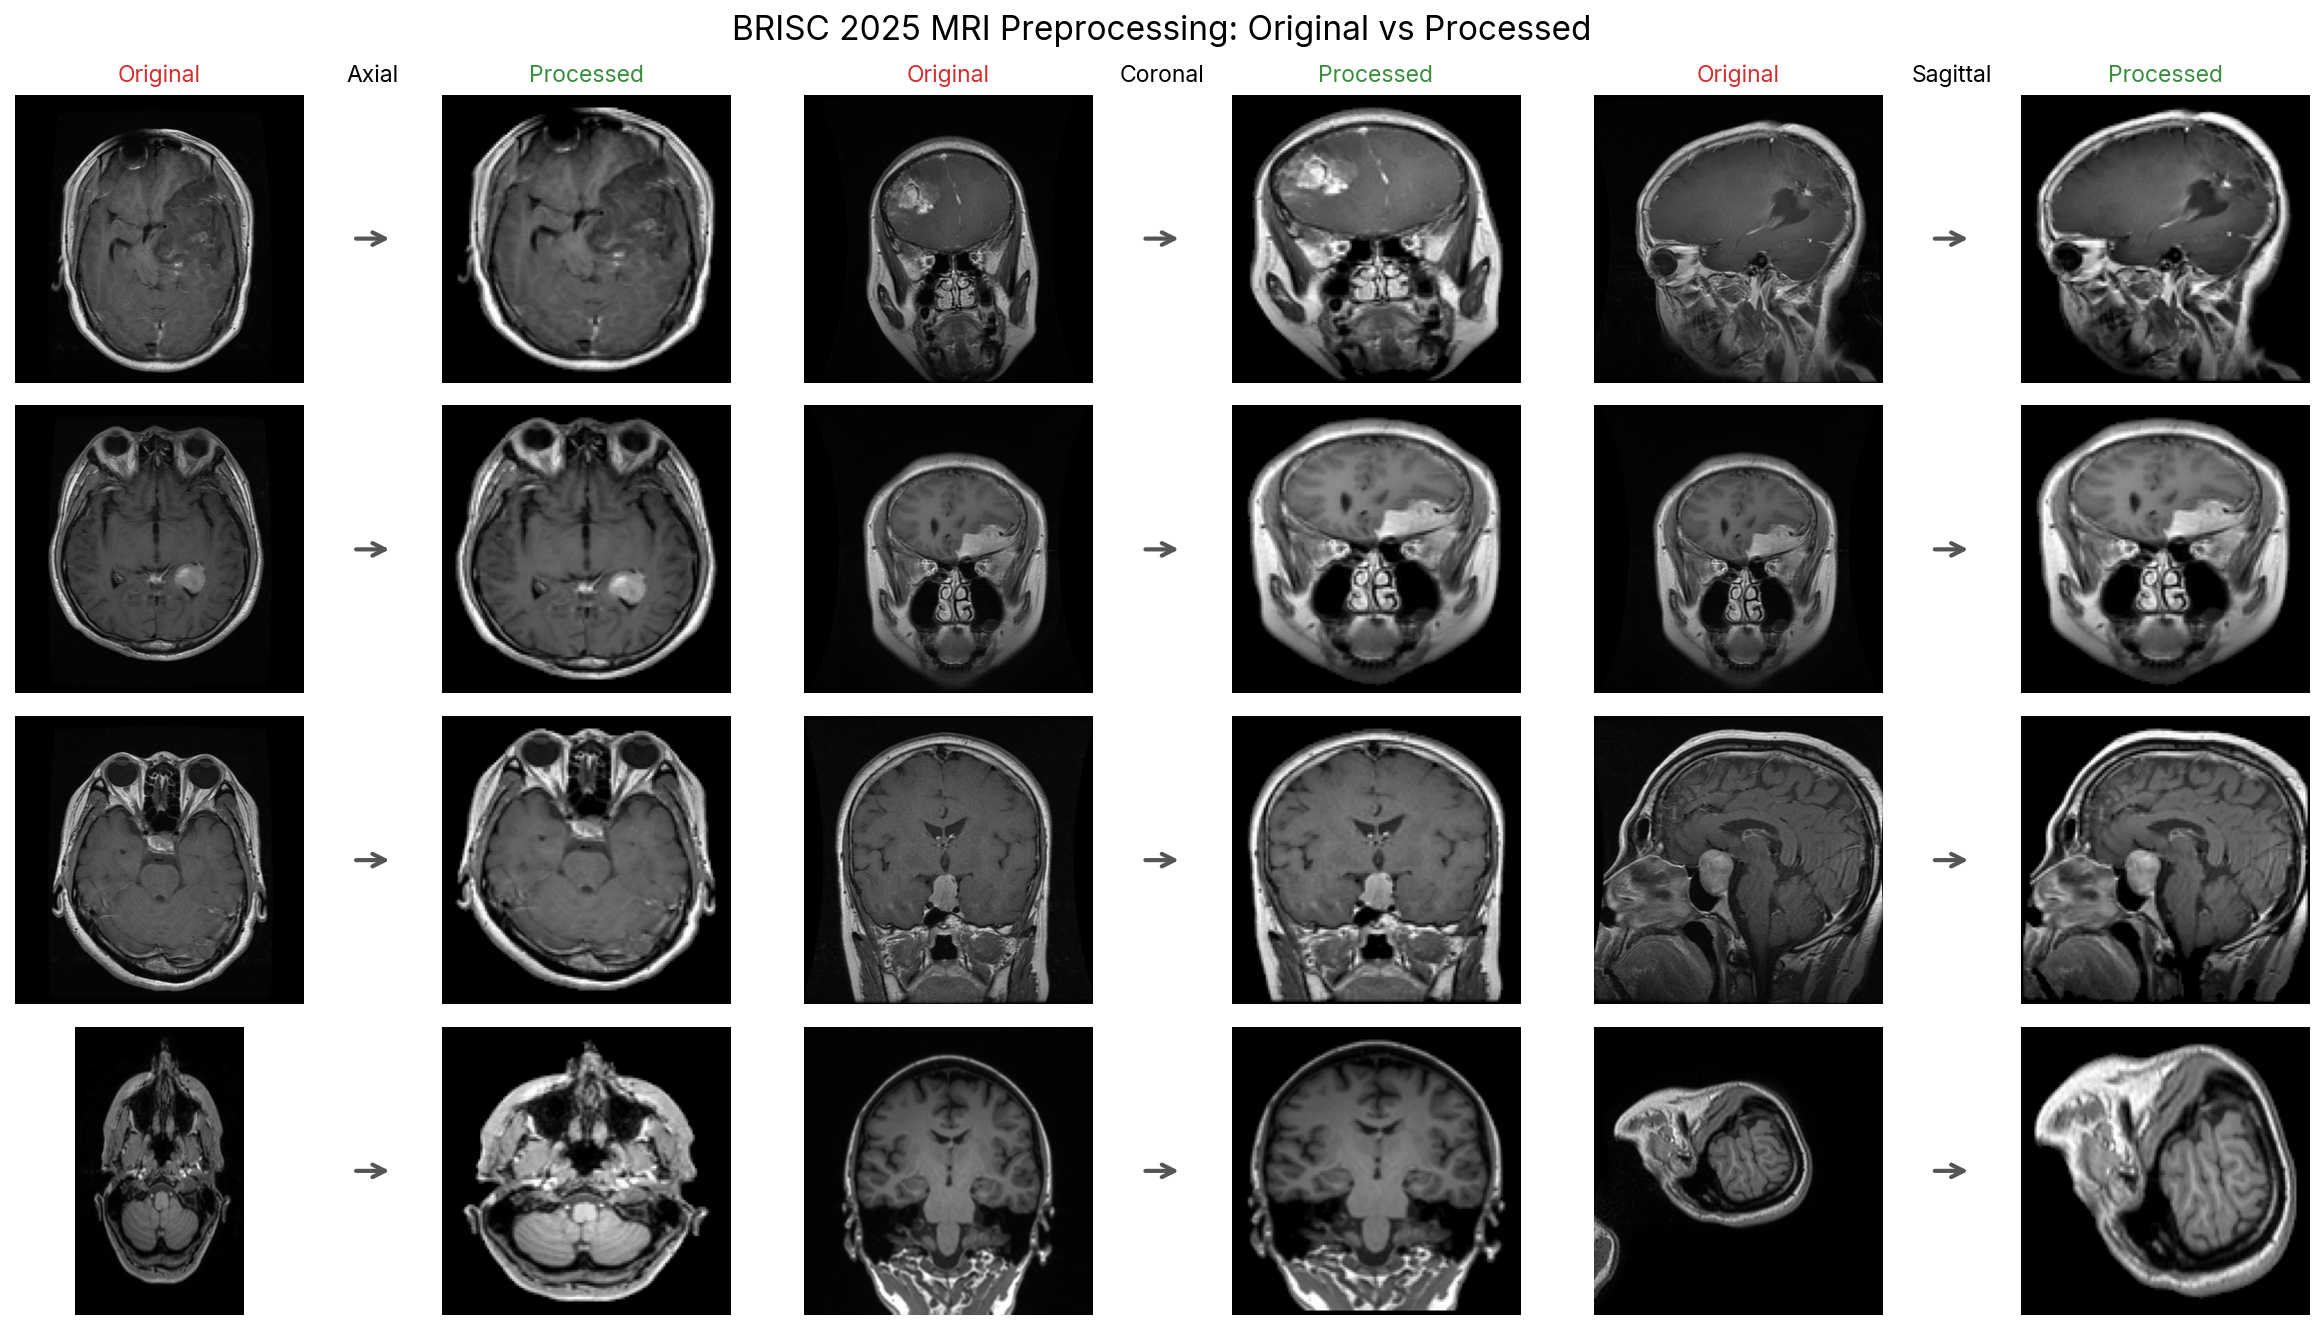

✅ SAVED FOR REPORT: ./figures/preprocessing_comparison.png

[Background Verification]
  glioma: ax:0, co:0, sa:1
  meningioma: ax:0, co:0, sa:0
  pituitary: ax:0, co:0, sa:4
  no_tumor: ax:0, co:0, sa:0


In [6]:
# =============================================================================
# CELL 6: PREPROCESSING VISUALIZATION — FOR REPORT
# Saves: preprocessing_comparison.png (report figure)
# =============================================================================
print("\n" + "="*70)
print("PREPROCESSING VISUALIZATION — FOR REPORT")
print("="*70)
# Colors for labels
WARNING_RED = '#D32F2F'    # Material Design Red 700
OK_GREEN = '#388E3C'       # Material Design Green 700

# Create figure with extra column for arrows
n_cols = len(PLANES) * 3  # Original, Arrow, Processed for each plane
fig, axes = plt.subplots(len(CLASSES), n_cols, figsize=(16, 9),
                         gridspec_kw={'width_ratios': [1, 0.15, 1] * len(PLANES)})

# Main title - heaviest weight
fig.suptitle('BRISC 2025 MRI Preprocessing: Original vs Processed', 
             fontsize=16, fontweight='heavy')

# Column headers with colored labels
for j, plane in enumerate(PLANES):
    col_orig = j * 3
    col_arrow = j * 3 + 1
    col_proc = j * 3 + 2
    
    # Plane name on arrow column — black color, bold weight
    plane_name = PLANE_CODES[plane].capitalize()
    axes[0, col_arrow].set_title(plane_name,
                                  fontweight='bold', fontsize=11,
                                  color='black')

    # Original label (red)
    axes[0, col_orig].set_title('Original', 
                                 fontweight='bold', fontsize=11,
                                 color=WARNING_RED)
    
    # Processed label (green)
    axes[0, col_proc].set_title('Processed', 
                                 fontweight='bold', fontsize=11,
                                 color=OK_GREEN)

for i, cls in enumerate(CLASSES):
    for j, plane in enumerate(PLANES):
        combo_key = (cls, plane)
        col_orig = j * 3
        col_arrow = j * 3 + 1
        col_proc = j * 3 + 2
        
        ax_orig = axes[i, col_orig]
        ax_arrow = axes[i, col_arrow]
        ax_proc = axes[i, col_proc]
        
        if combo_key in examples and examples[combo_key]:
            ex = examples[combo_key][0]
            ax_orig.imshow(ex['original'], cmap='gray')
            ax_proc.imshow(ex['final'], cmap='gray')
        
        # Turn off axes for images
        ax_orig.axis('off')
        ax_proc.axis('off')
        
        # Arrow column: draw arrow pointing right
        ax_arrow.axis('off')
        ax_arrow.set_xlim(0, 1)
        ax_arrow.set_ylim(0, 1)
        ax_arrow.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5),
                          arrowprops=dict(arrowstyle='->', color='#555555',
                                         lw=2, mutation_scale=15))
        
        # Row labels (class names) on leftmost column only
        if j == 0:
            ax_orig.set_ylabel(cls.replace('_', ' ').title(), 
                              fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./figures/preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SAVED FOR REPORT: ./figures/preprocessing_comparison.png")

# Quick verification (not saved)
print("\n[Background Verification]")
for cls in CLASSES:
    row = []
    for plane in PLANES:
        combo_key = (cls, plane)
        if combo_key in examples and examples[combo_key]:
            ex = examples[combo_key][0]
            corners = [ex['final'][:5, :5].mean(), ex['final'][:5, -5:].mean(),
                      ex['final'][-5:, :5].mean(), ex['final'][-5:, -5:].mean()]
            row.append(f"{plane}:{np.mean(corners):.0f}")
    print(f"  {cls}: {', '.join(row)}")

In [7]:
# =============================================================================
# CELL 7: CREATE ZIP FILES — PER CLASS-PLANE COMBINATION
# Creates 12 ZIPs: glioma_ax_128.zip, glioma_co_128.zip, etc.
# =============================================================================
print("\n" + "="*70)
print("CREATING ZIP ARCHIVES — PER PLANE  (for archival / export)")
print("="*70)
print(f"\nCreating {len(CLASSES) * len(PLANES)} ZIPs (one per class-plane combination)")

zip_counts = {}  # Track counts for verification

for cls in CLASSES:
    for plane in PLANES:
        combo_name = f"{cls}_{plane}"
        src = f"{PREPROCESSED_DIR}/{combo_name}"
        dst = f"{OUTPUT_DATA_DIR}/{combo_name}_{IMAGE_SIZE}.zip"
        
        if not os.path.exists(src):
            print(f"\n⚠️ {combo_name}: Source not found")
            zip_counts[(cls, plane)] = 0
            continue
        
        src_files = list(Path(src).glob('*.png'))
        src_count = len(src_files)
        
        if src_count == 0:
            print(f"\n⚠️ {combo_name}: No images")
            zip_counts[(cls, plane)] = 0
            continue
        
        # Remove old ZIP
        if os.path.exists(dst):
            try:
                os.remove(dst)
            except:
                pass
        
        print(f"\n📦 {combo_name}: {src_count} images → ZIP")
        
        # Create ZIP with resized images
        with zipfile.ZipFile(dst, 'w', zipfile.ZIP_DEFLATED) as zf:
            for img_path in src_files:
                img = Image.open(img_path).convert('L')
                img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
                # Save to bytes buffer
                buf = io.BytesIO()
                img.save(buf, format='PNG')
                buf.seek(0)
                zf.writestr(img_path.name, buf.read())
        
        # Verify
        if os.path.exists(dst):
            with zipfile.ZipFile(dst) as z:
                imgs = [f for f in z.namelist() if f.endswith('.png')]
                zip_counts[(cls, plane)] = len(imgs)
                mb = os.path.getsize(dst) / 1e6
                status = "✅" if len(imgs) == src_count else "⚠️"
                print(f"   {status} {len(imgs)} images, {mb:.1f} MB")
        else:
            print(f"   ❌ ZIP creation failed")
            zip_counts[(cls, plane)] = 0


CREATING ZIP ARCHIVES — PER PLANE  (for archival / export)

Creating 12 ZIPs (one per class-plane combination)

📦 glioma_ax: 394 images → ZIP
   ✅ 394 images, 3.4 MB

📦 glioma_co: 430 images → ZIP
   ✅ 430 images, 4.1 MB

📦 glioma_sa: 323 images → ZIP
   ✅ 323 images, 3.0 MB

📦 meningioma_ax: 423 images → ZIP
   ✅ 423 images, 3.7 MB

📦 meningioma_co: 426 images → ZIP
   ✅ 426 images, 4.0 MB

📦 meningioma_sa: 480 images → ZIP
   ✅ 480 images, 4.5 MB

📦 pituitary_ax: 426 images → ZIP
   ✅ 426 images, 4.0 MB

📦 pituitary_co: 510 images → ZIP
   ✅ 510 images, 5.2 MB

📦 pituitary_sa: 521 images → ZIP
   ✅ 521 images, 5.4 MB

📦 no_tumor_ax: 352 images → ZIP
   ✅ 352 images, 3.2 MB

📦 no_tumor_co: 310 images → ZIP
   ✅ 310 images, 2.9 MB

📦 no_tumor_sa: 405 images → ZIP
   ✅ 405 images, 4.0 MB



DATASET SAMPLES — FOR REPORT


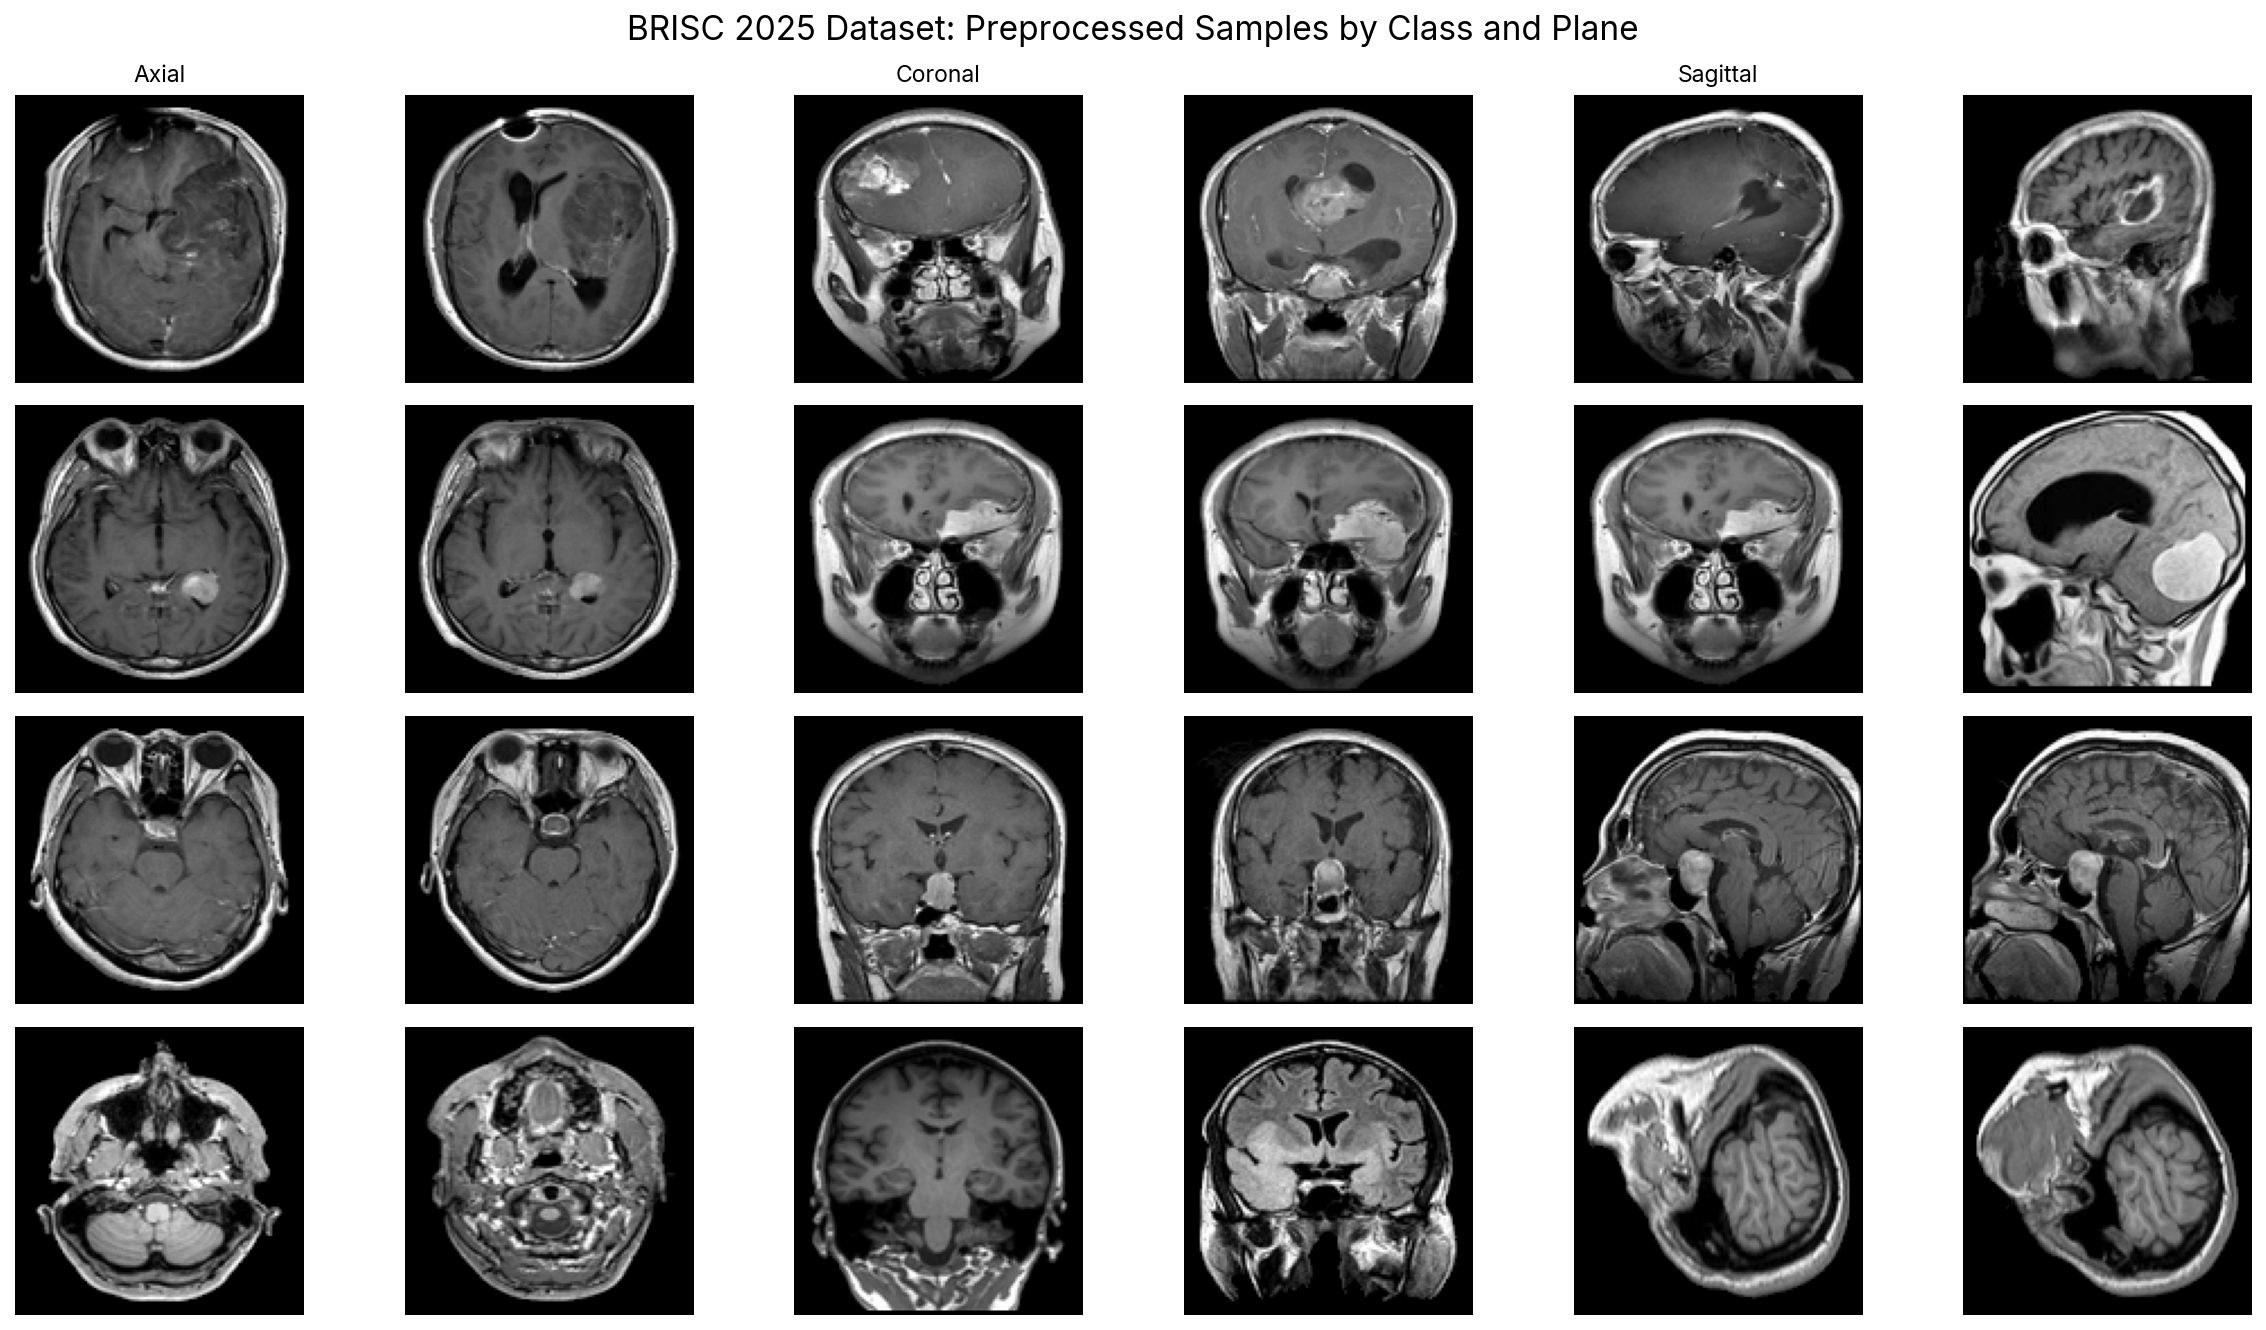

✅ SAVED FOR REPORT: ./figures/dataset_samples.png


In [8]:
# =============================================================================
# CELL 9: DATASET SAMPLES — FOR REPORT
# Saves: dataset_samples.png (report figure)
# =============================================================================
print("\n" + "="*70)
print("DATASET SAMPLES — FOR REPORT")
print("="*70)

# Create figures directory
os.makedirs('./figures', exist_ok=True)

fig, axes = plt.subplots(len(CLASSES), len(PLANES) * 2, figsize=(16, 9))

# Main title - extra bold (weight 800-900)
fig.suptitle('BRISC 2025 Dataset: Preprocessed Samples by Class and Plane', 
             fontsize=16, fontweight='black')

# Headers
for j, plane in enumerate(PLANES):
    mid = j * 2
    axes[0, mid].set_title(PLANE_CODES[plane].capitalize(), fontweight='bold', fontsize=11)

for i, cls in enumerate(CLASSES):
    for j, plane in enumerate(PLANES):
        combo_name = f"{cls}_{plane}"
        zp = f"{OUTPUT_DATA_DIR}/{combo_name}_{IMAGE_SIZE}.zip"
        base_col = j * 2
        
        if os.path.exists(zp):
            with zipfile.ZipFile(zp) as z:
                imgs = [f for f in z.namelist() if f.endswith('.png')][:2]
                for k, img_name in enumerate(imgs):
                    with z.open(img_name) as f:
                        img = Image.open(f)
                        axes[i, base_col + k].imshow(np.array(img), cmap='gray')
                        axes[i, base_col + k].axis('off')
        
        if j == 0:
            axes[i, 0].set_ylabel(cls.replace('_', ' ').title(), 
                                  fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./figures/dataset_samples.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SAVED FOR REPORT: ./figures/dataset_samples.png")

---

## Part II: StyleGAN2-ADA Implementation

The following cells configure and execute StyleGAN2-ADA training on the preprocessed BRISC 2025 data.

### Architecture Selection: StyleGAN2 vs StyleGAN3

While StyleGAN3 ("Alias-Free GAN") eliminates texture sticking artifacts through careful signal processing, **StyleGAN2-ADA** remains preferred for medical imaging due to:

1. **Training Stability**: StyleGAN2's architecture is more forgiving with limited data
2. **ADA Integration**: Native support for adaptive augmentation
3. **Computational Efficiency**: Lower VRAM requirements at equivalent quality
4. **Proven Medical Imaging Results**: Established track record in radiology synthesis

### Augmentation Strategy: The `bcf` Pipeline

Standard augmentation pipelines (`bgcfnc`) include geometric transforms that introduce artifacts in medical imaging:

| Component | Enabled | Rationale |
|-----------|---------|-----------|
| **b**lit (xflip) | Yes | Brain bilateral symmetry permits horizontal flipping |
| **g**eometric | No | Rotation/scaling distorts anatomical orientation |
| **c**olor | Yes | Intensity variation is natural in MRI acquisition |
| **f**ilter | Yes | Mild filtering augmentation |
| **n**oise | No | Synthetic noise differs from MRI noise characteristics |
| **c**utout | No | Creates rectangular artifacts on circular skull boundaries |

The `bcf` pipeline retains beneficial augmentations while eliminating those that introduce unrealistic artifacts.

---


---

### Hardware Configuration: RTX 5070 Optimization

Training is optimized for NVIDIA RTX 5070 (12.8 GB VRAM, Blackwell architecture):

| Parameter | Value | Memory Impact |
|-----------|-------|---------------|
| `batch-gpu` | 4 | Per-GPU batch size (fits in 12GB) |
| `batch` | 16 | Total batch via gradient accumulation |
| `fp16` | Auto | Mixed precision for memory efficiency |
| `workers` | 1 | DataLoader workers (Jupyter compatibility) |

### Training Duration Estimates

| KIMG | Wall Time (est.) | Checkpoints |
|------|------------------|-------------|
| 1000 | ~25 hours | 20 snapshots |
| 2000 | ~50 hours | 40 snapshots |
| 3000 | ~75 hours | 60 snapshots |

*Times estimated at ~90 sec/kimg with pure PyTorch fallback (no custom CUDA ops).*

---


In [ ]:
# =============================================================================
# CELL 12: CLONE STYLEGAN3 REPOSITORY AND INSTALL DEPENDENCIES
# =============================================================================
# This cell sets up the official NVlabs StyleGAN3 repository.
# Only needs to run once per environment.
#
# Expected Output:
#   - StyleGAN3 repository cloned to ./stylegan3/
#   - All dependencies installed (ninja, click, requests, etc.)
#   - Repository structure verified
# =============================================================================
import os
import sys
import subprocess
from pathlib import Path
from datetime import datetime

print("=" * 80)
print("StyleGAN2-ADA SETUP (via StyleGAN3 Codebase)")
print("=" * 80)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Setting up StyleGAN2-ADA (StyleGAN3 codebase)...")

# Define paths
STYLEGAN3_DIR = Path("./stylegan3")
STYLEGAN3_REPO = "https://github.com/NVlabs/stylegan3.git"

# Step 1: Clone repository if not exists
print("\n[STEP 1/4] Checking StyleGAN3 repository...")
if STYLEGAN3_DIR.exists() and (STYLEGAN3_DIR / "train.py").exists():
    print(f"  [OK] StyleGAN3 already cloned at: {STYLEGAN3_DIR.absolute()}")
else:
    print(f"  [INFO] Cloning StyleGAN3 from {STYLEGAN3_REPO}...")
    if STYLEGAN3_DIR.exists():
        import shutil
        shutil.rmtree(STYLEGAN3_DIR)
    result = subprocess.run(
        ["git", "clone", STYLEGAN3_REPO, str(STYLEGAN3_DIR)],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"  [OK] Successfully cloned to {STYLEGAN3_DIR.absolute()}")
    else:
        print(f"  [ERROR] Clone failed: {result.stderr}")
        raise RuntimeError("Failed to clone StyleGAN3 repository")

# Step 2: Install dependencies
print("\n[STEP 2/4] Installing StyleGAN3 dependencies...")
deps = [
    "click", "requests", "tqdm", "pyspng", "ninja", 
    "imageio-ffmpeg==0.4.3", "scipy", "scikit-image",
    "psutil", "munch"
]
for dep in deps:
    print(f"  Installing {dep}...", end=" ", flush=True)
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", dep],
        capture_output=True, text=True
    )
    print("[OK]" if result.returncode == 0 else f"[WARN] {result.stderr[:50]}")

# Step 3: Add StyleGAN3 to Python path
print("\n[STEP 3/4] Configuring Python path...")
stylegan3_path = str(STYLEGAN3_DIR.absolute())
if stylegan3_path not in sys.path:
    sys.path.insert(0, stylegan3_path)
    print(f"  [OK] Added to sys.path: {stylegan3_path}")
else:
    print(f"  [OK] Already in sys.path")

# Step 4: Verify installation
print("\n[STEP 4/4] Verifying StyleGAN3 installation...")
required_files = [
    "train.py", "generate_augmentation.py", "dataset_tool.py",
    "training/training_loop.py", "training/networks_stylegan2.py",
    "torch_utils/ops/conv2d_gradfix.py"
]
all_present = True
for f in required_files:
    fpath = STYLEGAN3_DIR / f
    status = "[OK]" if fpath.exists() else "[MISSING]"
    if not fpath.exists():
        all_present = False
    print(f"  {status} {f}")

if all_present:
    print("\n" + "=" * 80)
    print("[SUCCESS] StyleGAN3 repository ready!")
    print(f"  Location: {STYLEGAN3_DIR.absolute()}")
    print(f"  Train script: {STYLEGAN3_DIR.absolute() / 'train.py'}")
    print("=" * 80)
else:
    print("\n[ERROR] Some files missing - repository may be corrupted")
    print("  Try deleting ./stylegan3/ and re-running this cell")

In [ ]:
# =============================================================================
# CELL 12b: VERIFY CUDA PLUGINS
# =============================================================================
# Tests that all StyleGAN2-ADA CUDA plugins compile and load correctly.
# This ensures maximum training performance (~2-3x faster than CPU fallback).
#
# Expected Output:
#   - All three plugins show "Done. [OK]"
#   - Quick tensor operation test passes
#   - If any plugin fails, training will still work but slower
# =============================================================================
import sys
import warnings
warnings.filterwarnings('ignore', message='_get_vc_env is private')
import os
import torch
from pathlib import Path

# Ensure stylegan3 is in path
stylegan3_path = str(Path('./stylegan3').absolute())
if stylegan3_path not in sys.path:
    sys.path.insert(0, stylegan3_path)

print("="*60)
print("StyleGAN2-ADA CUDA PLUGIN VERIFICATION")
print("="*60)
print(f"\n[System]")
print(f"  PyTorch: {torch.__version__}")
print(f"  CUDA:    {torch.version.cuda}")
print(f"  GPU:     {torch.cuda.get_device_name(0)}")
print(f"  VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"\n[Loading CUDA Plugins]")
plugin_status = {'bias_act': False, 'upfirdn2d': False, 'filtered_lrelu': False}

try:
    from torch_utils.ops import bias_act
    x = torch.randn(1, 64, 8, 8, device='cuda')
    b = torch.randn(64, device='cuda')
    y = bias_act.bias_act(x, b, act='lrelu', impl='cuda')
    plugin_status['bias_act'] = True
except Exception as e:
    print(f"  [WARN] bias_act plugin failed: {e}")

try:
    from torch_utils.ops import upfirdn2d
    x = torch.randn(1, 64, 8, 8, device='cuda')
    f = torch.ones(4, device='cuda') / 4
    y = upfirdn2d.upfirdn2d(x, f, up=2, impl='cuda')
    plugin_status['upfirdn2d'] = True
except Exception as e:
    print(f"  [WARN] upfirdn2d plugin failed: {e}")

try:
    from torch_utils.ops import filtered_lrelu
    x = torch.randn(1, 64, 8, 8, device='cuda')
    y = filtered_lrelu.filtered_lrelu(x, impl='cuda')
    plugin_status['filtered_lrelu'] = True
except Exception as e:
    print(f"  [WARN] filtered_lrelu plugin failed: {e}")

# Summary
print(f"\n[Plugin Status]")
all_ok = True
for name, ok in plugin_status.items():
    status = "[OK]" if ok else "[FALLBACK]"
    print(f"  {name:20} {status}")
    if not ok:
        all_ok = False

print("\n" + "="*60)
if all_ok:
    print("ALL PLUGINS LOADED - Maximum training performance enabled!")
else:
    print("Some plugins using fallback - Training will work but slower")
print("="*60)

# Cleanup
del x, y, b, f
torch.cuda.empty_cache()

In [ ]:
# =============================================================================
# CELL 13: StyleGAN2-ADA CONFIGURATION - RTX 5070 OPTIMIZED
# =============================================================================
# Defines all hyperparameters for StyleGAN2-ADA training on small medical datasets.
# Configuration is optimized for:
#   - RTX 5070 (12.8 GB VRAM)
#   - ~400 images per class-plane combination
#   - 128x128 grayscale brain MRI
#
# Key Parameters Explained:
#   --cfg=stylegan2    : Uses StyleGAN2 backbone (proven for limited data)
#   --aug=ada          : Adaptive Discriminator Augmentation (CRITICAL!)
#   --gamma            : R1 regularization weight (scales with resolution^2)
#   --batch-gpu        : Images per GPU per step (VRAM dependent)
#   --kimg             : Total training images in thousands
# =============================================================================
import torch
from pathlib import Path
from datetime import datetime

print("=" * 80)
print("StyleGAN2-ADA CONFIGURATION - RTX 5070 OPTIMIZED")
print("=" * 80)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Configuring training parameters...\n")

# =============================================================================
# DIRECTORY STRUCTURE
# =============================================================================
STYLEGAN3_DIR = Path("./stylegan3")
STYLEGAN3_DATA = Path("./stylegan3_data")      # Prepared ZIP datasets
STYLEGAN3_OUT = Path("./stylegan3_results")    # Training outputs
FIGURES_DIR = Path("./figures")

# Create directories
for d in [STYLEGAN3_DATA, STYLEGAN3_OUT, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# =============================================================================
# IMAGE CONFIGURATION
# =============================================================================
IMG_RESOLUTION = 128    # 128x128 - optimal for ~400 image datasets
IMG_CHANNELS = 1        # Grayscale MRI

# =============================================================================
# HARDWARE CONFIGURATION (RTX 5070 - 12.8 GB VRAM)
# =============================================================================
if torch.cuda.is_available():
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_VRAM = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    GPU_COUNT = torch.cuda.device_count()
else:
    GPU_NAME = "CPU (No CUDA)"
    GPU_VRAM = 0
    GPU_COUNT = 0

# Dynamic batch size based on VRAM
if GPU_VRAM >= 20:
    BATCH_GPU = 16      # A100, A6000, etc.
    BATCH_TOTAL = 32
elif GPU_VRAM >= 12:
    BATCH_GPU = 8       # RTX 5070, 3080, 4080
    BATCH_TOTAL = 32    # Accumulates over 4 steps
elif GPU_VRAM >= 8:
    BATCH_GPU = 4       # RTX 3070, 4070
    BATCH_TOTAL = 16
else:
    BATCH_GPU = 2       # Low VRAM fallback
    BATCH_TOTAL = 8

# =============================================================================
# TRAINING HYPERPARAMETERS (Small Dataset Optimized)
# =============================================================================
# R1 regularization weight - scales quadratically with resolution
# 128x128 -> gamma=2.0, 256x256 -> gamma=8.0, 512x512 -> gamma=32.0
GAMMA = 2.0 if IMG_RESOLUTION <= 128 else (8.0 if IMG_RESOLUTION <= 256 else 32.0)

# Training duration in thousands of images
# Small datasets need ~2000-5000 kimg for convergence
KIMG = 3000             # 3M images seen total (good balance for ~400 samples)
SNAP = 10               # Save snapshot every 10 ticks (~40 kimg)
METRICS_EVERY = 50      # Calculate FID every 50 ticks

# Augmentation - CRITICAL for small datasets
AUG_MODE = "ada"        # Adaptive Discriminator Augmentation
AUG_PIPE = "bgcfnc"     # Blit, Geometric, Color, Filter, Noise, Cutout
AUG_TARGET = 0.6        # Target augmentation strength (0.6 is standard)

# StyleGAN2 config (proven for medical imaging)
CFG = "stylegan2"       # NOT stylegan3-t or stylegan3-r (those need more data)
MIRROR = 0              # Disable mirroring (brain anatomy is asymmetric)

# Optimizer settings
MAP_DEPTH = 2           # Mapping network depth (reduce for small data)
DLRATE = 0.002          # Discriminator learning rate
GLRATE = 0.0025         # Generator learning rate

# =============================================================================
# PER-PLANE TRAINING CONFIGURATION
# =============================================================================
CLASSES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
PLANES = ['ax', 'co', 'sa']
ALL_COMBOS = [f"{cls}_{pl}" for cls in CLASSES for pl in PLANES]

# =============================================================================
# DISPLAY CONFIGURATION SUMMARY
# =============================================================================
print("[HARDWARE]")
print(f"  GPU: {GPU_NAME}")
print(f"  VRAM: {GPU_VRAM:.1f} GB")
print(f"  GPU Count: {GPU_COUNT}")
print(f"  Batch per GPU: {BATCH_GPU}")
print(f"  Total Batch: {BATCH_TOTAL} (accumulates over {BATCH_TOTAL // BATCH_GPU} steps)")

print("\n[IMAGE]")
print(f"  Resolution: {IMG_RESOLUTION}x{IMG_RESOLUTION}")
print(f"  Channels: {IMG_CHANNELS} (grayscale)")

print("\n[TRAINING]")
print(f"  Config: {CFG}")
print(f"  Gamma (R1): {GAMMA}")
print(f"  Total kimg: {KIMG}")
print(f"  Augmentation: {AUG_MODE} (pipe={AUG_PIPE}, target={AUG_TARGET})")
print(f"  Mirroring: {'Enabled' if MIRROR else 'Disabled'}")
print(f"  Snapshot every: {SNAP} ticks")

print("\n[MODELS TO TRAIN]")
print(f"  Classes: {CLASSES}")
print(f"  Planes: {PLANES}")
print(f"  Total combinations: {len(ALL_COMBOS)}")
for i, combo in enumerate(ALL_COMBOS):
    print(f"    [{i+1:2d}] {combo}")

print("\n[DIRECTORIES]")
print(f"  StyleGAN3 repo: {STYLEGAN3_DIR.absolute()}")
print(f"  Dataset ZIPs: {STYLEGAN3_DATA.absolute()}")
print(f"  Output: {STYLEGAN3_OUT.absolute()}")

print("\n" + "=" * 80)
print("[OK] Configuration complete - ready for dataset preparation")
print("=" * 80)

In [ ]:
# =============================================================================
# CELL 14: PREPARE StyleGAN2-ADA DATASETS USING dataset_tool.py
# =============================================================================
# Converts preprocessed PNG folders to StyleGAN3-compatible ZIP archives.
# StyleGAN3 requires:
#   - Uncompressed ZIP files containing PNG images
#   - Images must be square and power-of-2 resolution
#   - Grayscale images should be converted to RGB (StyleGAN3 expects 3 channels)
#
# This cell processes all 12 class-plane combinations and creates:
#   ./stylegan3_data/glioma_ax.zip
#   ./stylegan3_data/glioma_co.zip
#   ... etc.
# =============================================================================
import subprocess
import zipfile
import io
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from datetime import datetime

print("=" * 80)
print("PREPARE StyleGAN2-ADA DATASETS")
print("=" * 80)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Converting preprocessed images to StyleGAN2-ADA format...\n")

# Source and destination directories
SRC_DIR = Path(PREPROCESSED_DIR)  # From Cell 5 preprocessing
DST_DIR = STYLEGAN3_DATA

print(f"[CONFIG]")
print(f"  Source: {SRC_DIR.absolute()}")
print(f"  Destination: {DST_DIR.absolute()}")
print(f"  Target resolution: {IMG_RESOLUTION}x{IMG_RESOLUTION}")
print(f"  Output channels: 3 (RGB - StyleGAN3 requirement)")

# =============================================================================
# METHOD 1: Manual ZIP creation (more control, works without dataset_tool.py)
# =============================================================================
def create_stylegan3_zip(src_folder, dst_zip, resolution=128):
    """
    Create StyleGAN3-compatible ZIP from folder of PNGs.
    
    StyleGAN3 expects:
    - Uncompressed ZIP (ZIP_STORED)
    - PNG images with consistent resolution
    - RGB format (3 channels)
    
    Args:
        src_folder: Path to folder containing PNG images
        dst_zip: Output ZIP path
        resolution: Target resolution (must be power of 2)
    
    Returns:
        int: Number of images processed
    """
    src_folder = Path(src_folder)
    dst_zip = Path(dst_zip)
    
    # Get all PNG files
    png_files = sorted(src_folder.glob("*.png"))
    if not png_files:
        return 0
    
    # Remove existing ZIP
    if dst_zip.exists():
        dst_zip.unlink()
    
    # Create ZIP with uncompressed storage (StyleGAN3 requirement)
    count = 0
    with zipfile.ZipFile(dst_zip, 'w', zipfile.ZIP_STORED) as zf:
        for png_path in png_files:
            try:
                # Load and convert to RGB
                img = Image.open(png_path)
                
                # Ensure correct size
                if img.size != (resolution, resolution):
                    img = img.resize((resolution, resolution), Image.LANCZOS)
                
                # Convert grayscale to RGB (StyleGAN3 expects 3 channels)
                if img.mode == 'L':
                    img = img.convert('RGB')
                elif img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Save to bytes buffer
                buf = io.BytesIO()
                img.save(buf, format='PNG', compress_level=0)  # No compression
                buf.seek(0)
                
                # Add to ZIP with simple numeric naming
                zf.writestr(f"{count:05d}.png", buf.read())
                count += 1
                
            except Exception as e:
                print(f"    [WARN] Failed to process {png_path.name}: {e}")
    
    return count

# =============================================================================
# Process all class-plane combinations
# =============================================================================
print("\n[PROCESSING]")
print(f"{'Combination':<20} {'Source':<10} {'Processed':<12} {'Size (MB)':<12} {'Status'}")
print("-" * 70)

dataset_stats = {}
total_images = 0
total_size = 0

for combo in ALL_COMBOS:
    src_folder = SRC_DIR / combo
    dst_zip = DST_DIR / f"{combo}.zip"
    
    if not src_folder.exists():
        print(f"{combo:<20} {'N/A':<10} {'N/A':<12} {'N/A':<12} [SKIP] Folder not found")
        dataset_stats[combo] = {'status': 'missing', 'count': 0}
        continue
    
    # Count source images
    src_count = len(list(src_folder.glob("*.png")))
    
    if src_count == 0:
        print(f"{combo:<20} {0:<10} {'N/A':<12} {'N/A':<12} [SKIP] No images")
        dataset_stats[combo] = {'status': 'empty', 'count': 0}
        continue
    
    # Create StyleGAN3 ZIP
    processed = create_stylegan3_zip(src_folder, dst_zip, IMG_RESOLUTION)
    
    # Get ZIP size
    if dst_zip.exists():
        size_mb = dst_zip.stat().st_size / (1024 * 1024)
        total_images += processed
        total_size += size_mb
        status = "[OK]" if processed == src_count else f"[WARN] {src_count - processed} failed"
        dataset_stats[combo] = {'status': 'ready', 'count': processed, 'size_mb': size_mb}
    else:
        size_mb = 0
        status = "[FAIL] ZIP not created"
        dataset_stats[combo] = {'status': 'failed', 'count': 0}
    
    print(f"{combo:<20} {src_count:<10} {processed:<12} {size_mb:<12.2f} {status}")

print("-" * 70)
print(f"{'TOTAL':<20} {'':<10} {total_images:<12} {total_size:<12.2f}")

# =============================================================================
# Verify ZIP contents
# =============================================================================
print("\n[VERIFICATION]")
all_ready = True
for combo in ALL_COMBOS:
    zip_path = DST_DIR / f"{combo}.zip"
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zf:
            imgs = [f for f in zf.namelist() if f.endswith('.png')]
            # Check first image dimensions
            if imgs:
                with zf.open(imgs[0]) as f:
                    img = Image.open(f)
                    w, h = img.size
                    ch = len(img.getbands())
                    status = "[OK]" if (w == IMG_RESOLUTION and h == IMG_RESOLUTION and ch == 3) else "[WARN]"
                    print(f"  {combo}: {len(imgs)} images, {w}x{h}x{ch} {status}")
                    if status == "[WARN]":
                        all_ready = False
            else:
                print(f"  {combo}: Empty ZIP [FAIL]")
                all_ready = False
    else:
        print(f"  {combo}: ZIP not found [FAIL]")
        all_ready = False

print("\n" + "=" * 80)
if all_ready:
    print("[SUCCESS] All 12 datasets prepared for StyleGAN2-ADA training!")
    print(f"  Location: {DST_DIR.absolute()}")
    print(f"  Total images: {total_images}")
    print(f"  Total size: {total_size:.2f} MB")
else:
    print("[WARNING] Some datasets have issues - check output above")
print("=" * 80)

In [ ]:
# =============================================================================
# CELL 15: STYLEGAN3 TRAINING FUNCTION - SINGLE MODEL
# =============================================================================
# Defines the training function that wraps StyleGAN3's train.py.
# Includes comprehensive logging, progress monitoring, and error handling.
#
# Key Features:
#   - Subprocess-based training (calls train.py with optimized arguments)
#   - Real-time progress parsing and display
#   - Automatic checkpoint management
#   - Memory-optimized settings for RTX 5070
# =============================================================================
import subprocess
import re
import json
import time
import signal
from pathlib import Path
from datetime import datetime, timedelta
from threading import Thread
from queue import Queue, Empty

print("=" * 80)
print("StyleGAN2-ADA TRAINING FUNCTION - DEFINED")
print("=" * 80)

def train_stylegan3(
    combo_name: str,
    data_zip: Path,
    outdir: Path,
    kimg: int = KIMG,
    gamma: float = GAMMA,
    batch: int = BATCH_TOTAL,
    batch_gpu: int = BATCH_GPU,
    cfg: str = CFG,
    aug: str = AUG_MODE,
    augpipe: str = AUG_PIPE,
    snap: int = SNAP,
    mirror: int = MIRROR,
    resume: str = None,
    dry_run: bool = False
):
    """
    Train a StyleGAN3 model on a single dataset.
    
    This function wraps the official NVlabs train.py script with optimized
    parameters for small medical imaging datasets and RTX 5070 hardware.
    
    Args:
        combo_name: Identifier for this training run (e.g., 'glioma_ax')
        data_zip: Path to StyleGAN3-formatted ZIP dataset
        outdir: Output directory for checkpoints and samples
        kimg: Total training images in thousands
        gamma: R1 regularization weight
        batch: Total batch size (accumulated)
        batch_gpu: Per-GPU batch size
        cfg: Configuration preset ('stylegan2', 'stylegan3-t', 'stylegan3-r')
        aug: Augmentation mode ('ada', 'noaug', 'fixed')
        augpipe: Augmentation pipeline ('bgcfnc', 'bg', 'blit', etc.)
        snap: Snapshot interval in ticks
        mirror: Enable horizontal mirroring (0 or 1)
        resume: Path to checkpoint to resume from (optional)
        dry_run: If True, only print command without executing
    
    Returns:
        dict: Training results including final checkpoint path and metrics
    """
    
    # Create output directory
    run_dir = outdir / combo_name
    run_dir.mkdir(parents=True, exist_ok=True)
    
    # Build training command
    train_script = STYLEGAN3_DIR / "train.py"
    
    cmd = [
        "python", str(train_script),
        f"--outdir={run_dir.resolve()}",
        f"--data={data_zip.resolve()}",
        f"--cfg={cfg}",
        f"--gpus=1",
        f"--batch={batch}",
        f"--batch-gpu={batch_gpu}",
        f"--gamma={gamma}",
        f"--kimg={kimg}",
        f"--snap={snap}",
        f"--aug={aug}",
        f"--mirror={mirror}",
        "--metrics=none",           # Disable metrics during training (compute separately)
        "--nobench=1",              # Reduce memory overhead
    ]
    
    # Add augmentation pipeline if using ADA
    if aug == "ada":
        cmd.append(f"--augpipe={augpipe}")
        cmd.append(f"--target={AUG_TARGET}")
    
    # Add resume checkpoint if provided
    if resume and Path(resume).exists():
        cmd.append(f"--resume={resume}")
    
    # Print command
    print("\n" + "-" * 80)
    print(f"[TRAINING] {combo_name}")
    print("-" * 80)
    print(f"[CMD] {' '.join(cmd)}")
    print(f"[OUT] {run_dir}")
    print(f"[DATA] {data_zip}")
    print(f"[CONFIG] cfg={cfg}, gamma={gamma}, batch={batch}x{batch_gpu}, kimg={kimg}")
    print(f"[AUG] mode={aug}, pipe={augpipe}, mirror={mirror}")
    
    if dry_run:
        print("[DRY RUN] Command not executed")
        return {"status": "dry_run", "cmd": cmd}
    
    # Execute training
    print("\n[STARTING TRAINING...]")
    print("=" * 80)
    
    start_time = time.time()
    result = {
        "combo": combo_name,
        "start_time": datetime.now().isoformat(),
        "cmd": " ".join(cmd),
        "status": "running"
    }
    
    try:
        # Run training process
        # Run training - let output print directly to avoid stdout conflicts
        # Note: Progress will be printed by train.py directly
        print("[Training output will appear below...]")
        
        import sys
        sys.stdout.flush()
        
        return_code = subprocess.call(cmd)
        
        last_tick = 0
        last_kimg = kimg  # Assume completed if return_code is 0
        g_losses = []
        d_losses = []
        
        elapsed_total = time.time() - start_time
        result["elapsed_seconds"] = elapsed_total
        result["elapsed_str"] = str(timedelta(seconds=int(elapsed_total)))
        result["final_kimg"] = last_kimg
        result["final_tick"] = last_tick
        
        if return_code == 0:
            result["status"] = "success"
            print("\n" + "=" * 80)
            print(f"[SUCCESS] Training completed for {combo_name}")
            print(f"  Duration: {result['elapsed_str']}")
            print(f"  Final kimg: {last_kimg:.1f}")
            
            # Find latest checkpoint
            ckpts = sorted(run_dir.glob("**/network-snapshot-*.pkl"))
            if ckpts:
                result["final_checkpoint"] = str(ckpts[-1])
                print(f"  Checkpoint: {ckpts[-1]}")
            
            # Save training history
            history = {
                "g_losses": g_losses,
                "d_losses": d_losses,
                "config": {
                    "combo": combo_name,
                    "kimg": kimg,
                    "gamma": gamma,
                    "batch": batch,
                    "cfg": cfg,
                    "aug": aug
                }
            }
            history_path = run_dir / "training_history.json"
            with open(history_path, 'w') as f:
                json.dump(history, f, indent=2)
            result["history_path"] = str(history_path)
            
        else:
            result["status"] = "failed"
            result["return_code"] = return_code
            print(f"\n[FAILED] Training failed with return code {return_code}")
    
    except KeyboardInterrupt:
        result["status"] = "interrupted"
        print("\n[INTERRUPTED] Training stopped by user")
        process.terminate()
    
    except Exception as e:
        result["status"] = "error"
        result["error"] = str(e)
        print(f"\n[ERROR] {e}")
    
    print("=" * 80)
    return result


# =============================================================================
# Quick test - dry run
# =============================================================================
print("\n[TEST] Dry run to verify command construction:")
test_result = train_stylegan3(
    combo_name="test_glioma_ax",
    data_zip=STYLEGAN3_DATA / "glioma_ax.zip",
    outdir=STYLEGAN3_OUT,
    kimg=100,  # Short test
    dry_run=True
)
print("\n[OK] Training function defined and ready")

---

### Training Execution

The cell below executes StyleGAN2-ADA training. Modify `COMBO` to select the model:

#### Model Glossary

| Class | Axial | Coronal | Sagittal | Description |
|-------|-------|---------|----------|-------------|
| **Glioma** | `glioma_ax` | `glioma_co` | `glioma_sa` | Grade II-IV diffuse gliomas |
| **Meningioma** | `meningioma_ax` | `meningioma_co` | `meningioma_sa` | Extra-axial dural tumors |
| **Pituitary** | `pituitary_ax` | `pituitary_co` | `pituitary_sa` | Sellar/parasellar adenomas |
| **No Tumor** | `no_tumor_ax` | `no_tumor_co` | `no_tumor_sa` | Healthy control subjects |

#### Output Structure

```
stylegan3_results/{COMBO}/
    00000-stylegan2-{COMBO}-gpus1-batch16-gamma2/
        training_options.json    # Full configuration
        log.txt                  # Training log
        reals.png               # Real samples (reference)
        fakes000000.png         # Generated samples (tick 0)
        fakes000200.png         # Generated samples (tick 200)
        network-snapshot-000200.pkl  # Model checkpoint
```

---


In [ ]:
# =============================================================================
# CELL 17: Flush GPU Memory (Run Before Training)
# =============================================================================
# Clears VRAM and Python cache before starting a new training run.
# Run this cell before training each new model.
# =============================================================================
import torch
import gc

print("Flushing GPU memory...")

# Clear Python garbage collector
gc.collect()

# Clear PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.synchronize()

    # Report status
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9

    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Total VRAM    : {total:.2f} GB")
    print(f"  Allocated     : {allocated:.2f} GB")
    print(f"  Reserved      : {reserved:.2f} GB")
    print(f"  Available     : {total - reserved:.2f} GB")
    print("\nMemory flushed! Ready for training.")
else:
    print("No CUDA device available")

In [ ]:
# =============================================================================
# CELL 17: StyleGAN2-ADA Training Execution
# =============================================================================
# Execute this cell to train a single class-plane model.
# Training progress displays in real-time below.
# =============================================================================
import os
os.environ['PYTHONUNBUFFERED'] = '1'

# =============================================================================
# CONFIGURATION
# =============================================================================
COMBO = "pituitary_ax"  # Model identifier (see glossary in markdown above)
KIMG = 1000              # Training duration in thousands of images

# =============================================================================
# EXECUTION
# =============================================================================
print(f"{'='*70}")
print(f"STYLEGAN2-ADA TRAINING: {COMBO}")
print(f"{'='*70}")
print(f"  Duration    : {KIMG} kimg")
print(f"  Augpipe     : cf (xflip + color + filter)")
print(f"  Snapshots   : Every ~50 kimg (12 ticks)")
print(f"  Output      : stylegan3_results/{COMBO}/")
print(f"{'-'*70}")
print()

!python stylegan3/train.py     --outdir=stylegan3_results/{COMBO}     --data=stylegan3_data/{COMBO}.zip     --cfg=stylegan2     --gpus=1     --batch=16     --batch-gpu=4     --gamma=2.0     --kimg={KIMG}     --snap=12     --aug=ada     --augpipe=bcf     --target=0.6     --mirror=0     --metrics=none     --workers=3

---

## Part III: Synthetic Image Generation & Evaluation

After training completes, the following cells:
1. **Generate synthetic images** from trained checkpoints
2. **Compare real vs. synthetic** samples visually
3. **Compute FID scores** to quantify generation quality
4. **Analyze training curves** for convergence validation

### Frechet Inception Distance (FID)

FID measures the distance between real and generated image distributions in Inception-v3 feature space. Lower values indicate higher quality.

| FID Range | Interpretation |
|-----------|----------------|
| < 50 | Excellent quality |
| 50-100 | Good quality |
| 100-150 | Moderate quality |
| > 150 | Poor quality |

*Note: Medical imaging FID thresholds differ from natural images due to lower intra-class variance.*

---


In [ ]:
import subprocess
subprocess.run(["pip", "install", "imagehash"], check=True)

In [ ]:
# =============================================================================
# CELL 19: Generate Synthetic Images (Self-Contained) — with deduplication
# =============================================================================
# Changes from v4:
#   - TARGET_PER_COMBO: desired total images per (class, plane) combination.
#   - REAL_DATASET_SIZE: number of real images already available for this combo.
#   - N_GENERATE is derived automatically as TARGET_PER_COMBO - REAL_DATASET_SIZE,
#     ensuring the augmented training set is balanced across all 12 combinations
#     regardless of how many real images each combo contributed.
#     This eliminates class-plane imbalance as a confound in the downstream
#     classifier experiment.
#
# Prior changes (v4):
#   - pHash deduplication (HASH_THRESHOLD).
#   - Per-image seed increments — no repeats on re-run.
#   - Three-metric consensus checkpoint selection (medically calibrated FID tiers,
#     Skandarani et al. 2023).
# =============================================================================

# ─── FLUSH GPU MEMORY ─────────────────────────────────────────────────────────
import torch
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory cleared: {torch.cuda.memory_allocated(0)/1e9:.2f} GB allocated")

# ─── IMPORTS ──────────────────────────────────────────────────────────────────
import sys
import json
import pickle
import imagehash

PROJECT_ROOT_STR = r"C:\Users\norie\iCloudDrive\Desktop\Education\Humber Polytechnic\Second Semester\AIGC 5504\Midterm_Proposal\Final_Project"
if PROJECT_ROOT_STR + "\\stylegan3" not in sys.path:
    sys.path.insert(0, PROJECT_ROOT_STR + "\\stylegan3")

import numpy as np
from PIL import Image
from pathlib import Path
from scipy import ndimage
from scipy.ndimage import label, binary_closing
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
from skimage.segmentation import flood_fill as sk_flood_fill

# ─── PATHS ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(r"C:\Users\norie\iCloudDrive\Desktop\Education\Humber Polytechnic\Second Semester\AIGC 5504\Midterm_Proposal\Final_Project")
RESULTS_DIR  = PROJECT_ROOT / "stylegan3_results"

# =============================================================================
# CONFIGURATION
# =============================================================================
COMBO            = "glioma_ax"  # glioma_ax/co/sa, meningioma_ax/co/sa,
                                # pituitary_ax/co/sa, no_tumor_ax/co/sa

# ── Balanced augmentation ─────────────────────────────────────────────────────
# TARGET_PER_COMBO : desired total images per (class × plane) combination.
#   All 12 combinations will be padded to this number with synthetic images,
#   normalising the joint class-plane distribution and eliminating dataset
#   size as a confound in the downstream classifier experiment.
#
# REAL_DATASET_SIZE: number of real training images for this combo.
#   N_GENERATE is computed as TARGET_PER_COMBO - REAL_DATASET_SIZE.
#   Set this accurately — it determines how many synthetic images are needed.
#
# Reference dataset sizes (BRISC 2025, training split):
#   glioma_ax=394  glioma_co=430  glioma_sa=323
#   meningioma_ax=423  meningioma_co=426  meningioma_sa=480
#   pituitary_ax=426   pituitary_co=510   pituitary_sa=521
#   no_tumor_ax=352    no_tumor_co=310    no_tumor_sa=405
TARGET_PER_COMBO = 2000
REAL_DATASET_SIZE = 394         # ← update per COMBO before running

N_GENERATE = TARGET_PER_COMBO - REAL_DATASET_SIZE  # computed automatically

TRUNCATION  = 0.85              # Truncation psi (0.5 = quality, 1.0 = diversity)
SEED        = 42                # Starting seed — each image gets SEED + i
NOISE_MODE  = "const"

# ── Checkpoint selection ──────────────────────────────────────────────────────
# "optimal" → three-metric consensus (FID tier + precision/recall tiebreak)
# "final"   → uses network-snapshot-001000.pkl regardless of metrics
#  <int>    → uses that specific kimg, e.g. CHECKPOINT = 336
CHECKPOINT  = "optimal"

# ── Three-metric consensus parameters (only used when CHECKPOINT = "optimal") ─
#
# FID tiers — medically calibrated per Skandarani et al. (2023):
#   state-of-the-art GANs on small medical datasets produce FIDs well above
#   100; values below 50 are exceptional; below 30 are extraordinary.
#   Do NOT use natural image thresholds here.
FID_TIERS = [
    (0,   30,  "EXTRAORDINARY"),
    (30,  50,  "EXCELLENT"),
    (50,  75,  "GOOD"),
    (75,  1e9, "FAIR"),
]

# Composite score weights within a tier.
# Equal weights (0.5/0.5) are empirically validated: precision degradation
# correlates with FID degradation at a >1:1 ratio across training trajectories,
# confirming that precision and recall contribute symmetrically.
PRECISION_WEIGHT    = 0.5
RECALL_WEIGHT       = 0.5

# Secondary tiebreak threshold: if top two composite scores differ by less
# than this value they are statistically indistinguishable → highest recall wins.
SCORE_TIE_THRESHOLD = 0.005

# ── Deduplication ─────────────────────────────────────────────────────────────
# pHash distance: 0 = identical, 64 = maximally different.
# 6 is conservative: catches visually identical images, allows genuine
# anatomical variation. Raise to 10 if rejection rate is too high.
HASH_THRESHOLD = 6

# =============================================================================
# VALIDATION
# =============================================================================
if N_GENERATE <= 0:
    raise ValueError(
        f"REAL_DATASET_SIZE ({REAL_DATASET_SIZE}) ≥ TARGET_PER_COMBO "
        f"({TARGET_PER_COMBO}). No synthetic images needed for {COMBO}."
    )

# =============================================================================
# PREPROCESSING (identical to Cell 5)
# =============================================================================
def _flood_fill_background(closed_binary):
    padded = np.pad(closed_binary, 2, mode='constant', constant_values=0)
    bg_map = (padded == 0).astype(np.uint8)
    filled = sk_flood_fill(bg_map, (0, 0), 2)
    return (filled == 2)[2:-2, 2:-2]

def _try_mask(img_array, thresh_fraction, close_iters):
    h, w = img_array.shape
    try:
        thresh = threshold_otsu(img_array) * thresh_fraction
    except Exception:
        thresh = 20.0
    binary = (img_array > thresh).astype(np.uint8)
    struct = ndimage.generate_binary_structure(2, 1)
    closed = binary_closing(
        binary, structure=ndimage.iterate_structure(struct, close_iters)
    ).astype(np.uint8)
    external_bg = _flood_fill_background(closed)
    brain_mask  = (~external_bg).astype(np.uint8)
    lbl, n = label(brain_mask)
    if n == 0:
        return None, 0.0
    sizes      = ndimage.sum(brain_mask, lbl, range(1, n + 1))
    brain_mask = (lbl == int(np.argmax(sizes) + 1)).astype(np.uint8)
    brain_mask = remove_small_objects(
        brain_mask.astype(bool), min_size=500
    ).astype(np.uint8)
    brain_mask = binary_closing(
        brain_mask, structure=ndimage.iterate_structure(struct, 3)
    ).astype(np.uint8)
    return brain_mask, float(brain_mask.mean())

def compute_skull_strip_mask(img_array):
    h, w = img_array.shape
    attempts = [(0.50, 5), (0.75, 5), (1.00, 7), (1.25, 7), (1.50, 5)]
    best_mask, best_dist = None, 1.0
    for thresh_frac, close_iters in attempts:
        mask, coverage = _try_mask(img_array, thresh_frac, close_iters)
        if mask is None:
            continue
        if 0.15 <= coverage <= 0.85:
            return mask
        dist = abs(coverage - 0.50)
        if dist < best_dist:
            best_mask, best_dist = mask, dist
    return best_mask if best_mask is not None else np.ones((h, w), dtype=np.uint8)

def normalize_intensity_with_mask(img_array, mask):
    brain_pixels = img_array[mask > 0]
    if len(brain_pixels) == 0:
        return ((img_array - img_array.min()) /
                (img_array.ptp() + 1e-8) * 255).astype(np.uint8)
    p1, p99     = np.percentile(brain_pixels, 1), np.percentile(brain_pixels, 99)
    normalized  = np.clip(img_array, p1, p99)
    normalized  = ((normalized - p1) / (p99 - p1 + 1e-8) * 255).astype(np.uint8)
    return normalized

def apply_preprocessing(pil_img):
    gray       = np.array(pil_img.convert('L'), dtype=np.float32)
    mask       = compute_skull_strip_mask(gray)
    normalized = normalize_intensity_with_mask(gray, mask)
    normalized = normalized * mask
    normalized[normalized < 11] = 0
    rgb = np.stack([normalized, normalized, normalized], axis=-1)
    return Image.fromarray(rgb.astype(np.uint8), mode='RGB')

# =============================================================================
# DEDUPLICATION HELPER
# =============================================================================
def is_duplicate(new_img: Image.Image, saved_hashes: list, threshold: int) -> bool:
    """
    Returns True if new_img is perceptually identical or near-identical
    to any image whose hash is already in saved_hashes.

    Uses pHash (perceptual hash): robust to minor pixel-level variation,
    contrast shifts, and JPEG artefacts while correctly flagging genuine
    copies.
    """
    new_hash = imagehash.phash(new_img)
    return any(abs(new_hash - h) <= threshold for h in saved_hashes)

# =============================================================================
# THREE-METRIC CONSENSUS CHECKPOINT SELECTION
# =============================================================================
def get_fid_tier(fid):
    for lo, hi, label in FID_TIERS:
        if lo <= fid < hi:
            return label, tier_order.index(label)
    return "FAIR", 3

tier_order = ["EXTRAORDINARY", "EXCELLENT", "GOOD", "FAIR"]

def resolve_checkpoint(model_dir, combo, checkpoint_spec):
    """
    Return (Path, kimg_label) using three-metric consensus selection.

    For checkpoint_spec == "optimal":
      1. Assign each checkpoint a medically calibrated FID tier.
      2. All checkpoints in the best (lowest) tier are FID-equivalent.
      3. Score tier members: PRECISION_WEIGHT*P + RECALL_WEIGHT*R.
      4. If top two scores within SCORE_TIE_THRESHOLD → recall tiebreak.
    """
    all_pkls = sorted(model_dir.glob("**/network-snapshot-*.pkl"))
    if not all_pkls:
        raise FileNotFoundError(f"No checkpoints found in {model_dir}")

    if checkpoint_spec == "final":
        matches = [p for p in all_pkls if p.name == "network-snapshot-001000.pkl"]
        if not matches:
            raise FileNotFoundError("network-snapshot-001000.pkl not found.")
        return matches[0], 1000

    elif checkpoint_spec == "optimal":
        json_candidates = list(model_dir.glob(f"**/checkpoint_metrics_{combo}.json"))
        if not json_candidates:
            raise FileNotFoundError(
                f"checkpoint_metrics_{combo}.json not found under {model_dir}.\n"
                f"Run the checkpoint evaluation cell first, or set CHECKPOINT "
                f"to a kimg integer."
            )
        with open(json_candidates[0]) as f:
            metrics = json.load(f)

        candidates = [(int(k), v) for k, v in metrics.items() if int(k) > 0]
        candidates.sort(key=lambda x: x[0])
        for k, v in candidates:
            v["tier"], v["tier_rank"] = get_fid_tier(v["fid"])

        best_tier_rank = min(v["tier_rank"] for _, v in candidates)
        best_tier      = tier_order[best_tier_rank]
        plateau        = [(k, v) for k, v in candidates
                          if v["tier_rank"] == best_tier_rank]

        print(f"\n  {'─'*62}")
        print(f"  CHECKPOINT SELECTION AUDIT — {combo}")
        print(f"  {'─'*62}")
        print(f"  Best FID tier      : {best_tier}  "
              f"(FID bounds: {FID_TIERS[best_tier_rank][0]}–"
              f"{FID_TIERS[best_tier_rank][1]})")
        print(f"  Plateau size       : {len(plateau)} checkpoint(s) in tier")
        print(f"  Weights            : P={PRECISION_WEIGHT}, R={RECALL_WEIGHT}  |  "
              f"Tie threshold: {SCORE_TIE_THRESHOLD}")
        print()

        if len(plateau) == 1:
            best_kimg, best_entry = plateau[0]
            print(f"  Decision           : FID unambiguous — single tier member")
        else:
            scored = sorted(
                [(k, v, PRECISION_WEIGHT * v["precision"] +
                         RECALL_WEIGHT   * v["recall"])
                 for k, v in plateau],
                key=lambda x: x[2], reverse=True
            )

            print(f"  {'kimg':>6}  {'FID':>8}  {'Prec':>7}  {'Rec':>7}  {'Score':>7}")
            print(f"  {'─'*6}  {'─'*8}  {'─'*7}  {'─'*7}  {'─'*7}")

            top_k, top_v, top_score = scored[0]
            sec_k, sec_v, sec_score = scored[1]
            gap = top_score - sec_score

            if gap <= SCORE_TIE_THRESHOLD:
                if sec_v["recall"] > top_v["recall"]:
                    best_kimg, best_entry = sec_k, sec_v
                    decision = (f"composite tie (gap={gap:.4f}) → "
                                f"recall tiebreak → rank-2 wins")
                else:
                    best_kimg, best_entry = top_k, top_v
                    decision = (f"composite tie (gap={gap:.4f}) → "
                                f"recall tiebreak → rank-1 holds")
            else:
                best_kimg, best_entry = top_k, top_v
                decision = f"composite score decisive (gap={gap:.4f})"

            for k, v, score in scored:
                marker = "  ← selected" if k == best_kimg else ""
                print(f"  {k:>6}  {v['fid']:>8.4f}  "
                      f"{v['precision']:>7.4f}  {v['recall']:>7.4f}  "
                      f"{score:>7.4f}{marker}")
            print()
            print(f"  Decision           : {decision}")

        print()
        print(f"  ✅ Selected        : {best_entry['checkpoint']}  "
              f"(kimg={best_kimg}, FID={best_entry['fid']:.4f}, "
              f"P={best_entry['precision']:.4f}, R={best_entry['recall']:.4f})")
        print(f"  {'─'*62}\n")

        matches = [p for p in all_pkls if p.name == best_entry["checkpoint"]]
        if not matches:
            raise FileNotFoundError(
                f"Optimal checkpoint {best_entry['checkpoint']} not found on disk."
            )
        return matches[0], best_kimg

    elif isinstance(checkpoint_spec, int):
        target  = f"network-snapshot-{checkpoint_spec:06d}.pkl"
        matches = [p for p in all_pkls if p.name == target]
        if not matches:
            raise FileNotFoundError(f"{target} not found under {model_dir}.")
        return matches[0], checkpoint_spec

    else:
        raise ValueError(
            f"CHECKPOINT must be 'optimal', 'final', or an integer kimg. "
            f"Got: {checkpoint_spec!r}"
        )

# =============================================================================
# MAIN
# =============================================================================
print(f"{'='*70}")
print(f"SYNTHETIC IMAGE GENERATION: {COMBO}")
print(f"  Target per combo   : {TARGET_PER_COMBO}")
print(f"  Real dataset size  : {REAL_DATASET_SIZE}")
print(f"  Synthetic to generate: {N_GENERATE}  "
      f"({REAL_DATASET_SIZE} + {N_GENERATE} = {TARGET_PER_COMBO})")
print(f"  pHash threshold    : {HASH_THRESHOLD}")
print(f"{'='*70}")

model_dir = RESULTS_DIR / COMBO

try:
    checkpoint, kimg_used = resolve_checkpoint(model_dir, COMBO, CHECKPOINT)
    out_dir = model_dir / "synthetic"
    out_dir.mkdir(exist_ok=True)

    print(f"  Checkpoint  : {checkpoint.name}  ({kimg_used} kimgs)")
    print(f"  Output      : {out_dir}")
    print(f"  Images      : {N_GENERATE}")
    print(f"  Truncation  : {TRUNCATION}")
    print(f"  Start seed  : {SEED}  (increments per image — no repeats on re-run)")
    print(f"{'-'*70}")

    # ── Load generator ────────────────────────────────────────────────────────
    print("\nLoading generator...", end=" ", flush=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with open(checkpoint, 'rb') as f:
        G = pickle.load(f)['G_ema'].eval().to(device)
    print(f"OK (device={device})")

    # ── Class / plane codes ───────────────────────────────────────────────────
    parts      = COMBO.split('_')
    cls_map    = {'glioma': 'gl', 'meningioma': 'me', 'pituitary': 'pi', 'no_tumor': 'nt'}
    cls_code   = cls_map.get(parts[0], parts[0][:2]) if len(parts) == 2 else COMBO[:2]
    plane_code = parts[1] if len(parts) == 2 else 'ax'

    # ── Generate ──────────────────────────────────────────────────────────────
    print(f"\nGenerating {N_GENERATE} distinct images...")
    saved_hashes  = []
    saved         = 0
    rejected_qual = 0
    rejected_dup  = 0
    attempt       = 0

    with torch.no_grad():
        while saved < N_GENERATE:
            seed_i = SEED + attempt
            rng    = torch.Generator(device=device)
            rng.manual_seed(seed_i)
            attempt += 1

            z   = torch.randn(1, G.z_dim, generator=rng, device=device)
            img = G(z, None, truncation_psi=TRUNCATION, noise_mode=NOISE_MODE)
            img = (img[0] * 127.5 + 128).clamp(0, 255).permute(1, 2, 0).cpu().numpy().astype(np.uint8)
            pil_raw = Image.fromarray(img)

            preprocessed = apply_preprocessing(pil_raw)

            if np.array(preprocessed.convert('L')).mean() < 10:
                rejected_qual += 1
                continue

            if is_duplicate(preprocessed, saved_hashes, HASH_THRESHOLD):
                rejected_dup += 1
                continue

            saved_hashes.append(imagehash.phash(preprocessed))
            filename = f"brisc2025_synth_{saved+1:05d}_{cls_code}_{plane_code}_t1.png"
            preprocessed.save(out_dir / filename)
            saved += 1

            if saved % 100 == 0 or saved == N_GENERATE:
                dup_pct  = 100 * rejected_dup  / attempt
                qual_pct = 100 * rejected_qual / attempt
                print(f"  {saved:4d}/{N_GENERATE}  "
                      f"attempts={attempt}  "
                      f"dup_rejected={rejected_dup} ({dup_pct:.1f}%)  "
                      f"qual_rejected={rejected_qual} ({qual_pct:.1f}%)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"COMPLETE")
    print(f"  Saved            : {saved} synthetic images")
    print(f"  Real images      : {REAL_DATASET_SIZE}")
    print(f"  Total for combo  : {saved + REAL_DATASET_SIZE}  "
          f"(target: {TARGET_PER_COMBO})")
    print(f"  Total attempts   : {attempt}")
    print(f"  Quality rejects  : {rejected_qual}  ({100*rejected_qual/attempt:.1f}%)")
    print(f"  Dup rejects      : {rejected_dup}  ({100*rejected_dup/attempt:.1f}%)")
    print(f"  Output           : {out_dir}")
    print(f"{'='*70}")
    print()
    print("NOTE: if dup_rejected > 10% of attempts, consider raising TRUNCATION")
    print("      (e.g. 0.85 → 0.90) to increase latent space diversity.")

    del G
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

except FileNotFoundError as e:
    print(f"\nERROR: {e}")

In [ ]:
# =============================================================================
# CELL 20: Real vs Synthetic Comparison (Self-Contained)
# =============================================================================
# This cell is SELF-CONTAINED - no previous cells required.
# Creates side-by-side comparison of real and synthetic images.
# =============================================================================

# ─── IMPORTS ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path
import random

# ─── PATHS ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(r"C:\Users\norie\iCloudDrive\Desktop\Education\Humber Polytechnic\Second Semester\AIGC 5504\Midterm_Proposal\Final_Project")
PREPROCESSED_DIR = PROJECT_ROOT / "brisc2025_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "stylegan3_results"

# =============================================================================
# CONFIGURATION
# =============================================================================
COMBO = "glioma_sa"    # Model to compare
N_SAMPLES = 8          # Samples per row
SEED = 42

# =============================================================================
# LOAD AND DISPLAY
# =============================================================================
print(f"{'='*70}")
print(f"REAL vs SYNTHETIC: {COMBO}")
print(f"{'='*70}")

real_dir = PREPROCESSED_DIR / COMBO
synth_dir = RESULTS_DIR / COMBO / "synthetic"

if not real_dir.exists():
    print(f"ERROR: Real images not found at {real_dir}")
elif not synth_dir.exists():
    print(f"ERROR: Synthetic images not found. Run Cell 19 first.")
else:
    real_imgs = sorted(real_dir.glob("*.png")) + sorted(real_dir.glob("*.jpg"))
    synth_imgs = sorted(synth_dir.glob("*.png"))

    print(f"  Real: {len(real_imgs)} | Synthetic: {len(synth_imgs)}")

    if len(real_imgs) > 0 and len(synth_imgs) > 0:
        random.seed(SEED)
        real_sample = random.sample(real_imgs, min(N_SAMPLES, len(real_imgs)))
        synth_sample = random.sample(synth_imgs, min(N_SAMPLES, len(synth_imgs)))

        fig, axes = plt.subplots(2, N_SAMPLES, figsize=(N_SAMPLES*2, 4.5))
        fig.suptitle(f'{COMBO.replace("_", " ").title()}: Real (top) vs Synthetic (bottom)',
                     fontsize=14, fontweight='bold')

        for i, img_path in enumerate(real_sample):
            axes[0, i].imshow(Image.open(img_path), cmap='gray')
            axes[0, i].axis('off')

        for i, img_path in enumerate(synth_sample):
            axes[1, i].imshow(Image.open(img_path), cmap='gray')
            axes[1, i].axis('off')

        plt.tight_layout()
        save_path = RESULTS_DIR / COMBO / f"comparison_{COMBO}.png"
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")
        plt.show()


In [ ]:
# =============================================================================
# CELL: Checkpoint Selection — Full Evaluation + Publication Plot
# =============================================================================
# Evaluates FID (+ optionally Precision/Recall) at every saved checkpoint,
# saves results to JSON, then generates a publication-quality figure.
#
# LIGHTWEIGHT MODE: set LIGHTWEIGHT=True when training is running in parallel.
#   - Drops pr50k3_full (halves compute time per checkpoint)
#   - Runs calc_metrics at below-normal process priority (Windows)
#   - Suppresses verbose per-line output, shows tqdm progress bar instead
#
# FULLY AUTOMATIC — no hardcoded values. Set COMBO and run.
# Resume-safe: already-evaluated checkpoints are skipped on re-run.
# =============================================================================

import sys
import subprocess
import json
import re
import gc
import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from pathlib import Path
from datetime import datetime

try:
    from tqdm.notebook import tqdm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "tqdm", "-q"], check=True)
    from tqdm.notebook import tqdm

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
COMBO        = "meningioma_ax"        # glioma_ax/co/sa    | meningioma_ax/co/sa
                                  # pituitary_ax/co/sa | no_tumor_ax/co/sa

LIGHTWEIGHT  = False              # True  → FID only, low priority, quiet output
                                  # False → FID + Precision + Recall, full output

# ─── PATHS ────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path(r"C:\Users\norie\iCloudDrive\Desktop\Education\Humber Polytechnic\Second Semester\AIGC 5504\Midterm_Proposal\Final_Project")
RESULTS_DIR   = PROJECT_ROOT / "stylegan3_results"
DATA_DIR      = PROJECT_ROOT / "stylegan3_data"
STYLEGAN3_DIR = PROJECT_ROOT / "stylegan3"

METRICS = "fid50k_full" if LIGHTWEIGHT else "fid50k_full,pr50k3_full"

# Windows BELOW_NORMAL_PRIORITY_CLASS flag — reduces CPU/IO competition
# with the training job without starving it of GPU
PRIORITY_FLAG = 0x00004000 if (LIGHTWEIGHT and sys.platform == "win32") else 0

model_dir  = RESULTS_DIR / COMBO
real_zip   = DATA_DIR / f"{COMBO}.zip"
run_dirs   = sorted([d for d in model_dir.iterdir() if d.is_dir() and d.name[0].isdigit()])
if not run_dirs:
    raise RuntimeError(f"No run directories found in {model_dir}")
latest_run = run_dirs[-1]
out_json   = latest_run / f"checkpoint_metrics_{COMBO}.json"

# Find all checkpoints sorted by kimg
checkpoints = []
for ckpt in sorted(latest_run.glob("network-snapshot-*.pkl")):
    m = re.search(r'network-snapshot-(\d+)\.pkl', ckpt.name)
    if m:
        checkpoints.append((int(m.group(1)), ckpt))
checkpoints.sort()

# =============================================================================
# STEP 1 — EVALUATE ALL CHECKPOINTS
# =============================================================================
mode_str = "LIGHTWEIGHT (FID only, low priority)" if LIGHTWEIGHT else "FULL (FID + Precision + Recall)"
print("=" * 65)
print(f"CHECKPOINT EVALUATION + PLOT: {COMBO}")
print("=" * 65)
print(f"  Mode        : {mode_str}")
print(f"  Run dir     : {latest_run.name}")
print(f"  Dataset     : {real_zip.name}")
print(f"  Metrics     : {METRICS}")
print(f"  Checkpoints : {len(checkpoints)}")
for kimg, ckpt in checkpoints:
    print(f"    {kimg:6d} kimgs — {ckpt.name}")
est_min = len(checkpoints) * (8 if LIGHTWEIGHT else 15)
print(f"  Est. time   : ~{est_min} minutes")
print(f"  Started     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 65)

# Load existing results (resume if interrupted)
all_results = {}
if out_json.exists():
    with open(out_json) as f:
        all_results = json.load(f)
    already = len(all_results)
    if already > 0:
        print(f"\nResuming — {already} checkpoint(s) already evaluated:")
        for k in sorted(all_results.keys(), key=int):
            r = all_results[k]
            fid_str  = f"{r['fid']:.2f}"       if r.get('fid')       is not None else "---"
            prec_str = f"{r['precision']:.4f}" if r.get('precision') is not None else "---"
            rec_str  = f"{r['recall']:.4f}"    if r.get('recall')    is not None else "---"
            print(f"  {int(k):6d} kimgs → FID: {fid_str}  P: {prec_str}  R: {rec_str}")

# Filter to unevaluated checkpoints only
pending = [(k, c) for k, c in checkpoints if str(k) not in all_results]
print(f"\n  {len(pending)} checkpoint(s) remaining.\n")

# ── Main evaluation loop ──────────────────────────────────────────────────────
pbar = tqdm(
    pending,
    desc=f"Evaluating {COMBO}",
    unit="ckpt",
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt}  [{elapsed}<{remaining}]"
)

for kimg, ckpt in pbar:
    key = str(kimg)
    pbar.set_postfix({"kimg": kimg, "status": "running..."})

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    cmd = [
        sys.executable,
        str(STYLEGAN3_DIR / "calc_metrics.py"),
        f"--metrics={METRICS}",
        f"--data={real_zip}",
        f"--network={ckpt}",
        "--gpus=1",
        "--mirror=0",
    ]

    fid, precision, recall = None, None, None
    all_output_lines = []

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        cwd=str(STYLEGAN3_DIR),
        bufsize=1,
        creationflags=PRIORITY_FLAG,  # low priority on Windows, no-op elsewhere
    )

    for line in process.stdout:
        stripped_line = line.rstrip()
        all_output_lines.append(stripped_line)

        if not LIGHTWEIGHT:
            # Full mode: print every line
            print(f"  {stripped_line}", flush=True)
        else:
            # Lightweight mode: only update postfix on every 10k items
            m = re.search(r'items\s+(\d+)', stripped_line)
            if m and int(m.group(1)) % 10000 == 0:
                pbar.set_postfix({"kimg": kimg, "items": m.group(1)})

        # Parse JSON result lines
        clean = stripped_line.strip()
        if clean.startswith("{"):
            try:
                data = json.loads(clean)
                res  = data.get("results", {})
                if "fid50k_full" in res:
                    fid = res["fid50k_full"]
                if "pr50k3_full_precision" in res:
                    precision = res["pr50k3_full_precision"]
                    recall    = res["pr50k3_full_recall"]
            except json.JSONDecodeError:
                pass

    process.wait()

    if fid is not None:
        entry = {
            "kimg"      : kimg,
            "fid"       : round(fid, 4),
            "precision" : round(precision, 6) if precision is not None else None,
            "recall"    : round(recall, 6)    if recall    is not None else None,
            "checkpoint": ckpt.name,
            "timestamp" : datetime.now().isoformat(),
        }
        all_results[key] = entry
        with open(out_json, "w") as f:
            json.dump(all_results, f, indent=2)

        fid_str  = f"{fid:.2f}"
        prec_str = f"{precision:.4f}" if precision is not None else "N/A"
        rec_str  = f"{recall:.4f}"    if recall    is not None else "N/A"
        pbar.set_postfix({"kimg": kimg, "FID": fid_str})
        tqdm.write(f"  ✅ {kimg:6d} kimgs → FID: {fid_str}  P: {prec_str}  R: {rec_str}  "
                   f"({datetime.now().strftime('%H:%M:%S')})")
    else:
        pbar.set_postfix({"kimg": kimg, "status": "FAILED"})
        tqdm.write(f"  ❌ {kimg:6d} kimgs — could not parse metrics.")
        tqdm.write(f"     Last lines: {all_output_lines[-5:]}")

pbar.close()

# Evaluation summary table
print(f"\n{'=' * 65}")
print("EVALUATION COMPLETE")
print(f"{'=' * 65}")
print(f"  {'kimg':>8}  {'FID':>10}  {'Precision':>10}  {'Recall':>10}")
print(f"  {'-'*8}  {'-'*10}  {'-'*10}  {'-'*10}")
sorted_results = sorted(all_results.items(), key=lambda x: int(x[0]))
best_fid_kimg, best_fid_val = None, float("inf")
for key, r in sorted_results:
    fid_str  = f"{r['fid']:.2f}"       if r.get('fid')       is not None else "---"
    prec_str = f"{r['precision']:.4f}" if r.get('precision') is not None else "---"
    rec_str  = f"{r['recall']:.4f}"    if r.get('recall')    is not None else "---"
    print(f"  {int(key):>8}  {fid_str:>10}  {prec_str:>10}  {rec_str:>10}")
    if r.get('fid') is not None and r['fid'] < best_fid_val:
        best_fid_val  = r['fid']
        best_fid_kimg = r['kimg']

if best_fid_kimg:
    final_kimg = max(int(k) for k in all_results.keys())
    final_fid  = all_results[str(final_kimg)]['fid']
    delta      = final_fid - best_fid_val
    print(f"\n  ✅ Best FID : {best_fid_val:.2f} at {best_fid_kimg} kimgs")
    if best_fid_kimg != final_kimg:
        print(f"  ⚠️  Optimal checkpoint is NOT the final one (Δ {delta:+.2f})")
        print(f"     Use network-snapshot-{best_fid_kimg:06d}.pkl for generation.")

# =============================================================================
# STEP 2 — LOAD TRAINING STATS
# =============================================================================
print(f"\n{'=' * 65}")
print("STEP 2: GENERATING PLOTS")
print(f"{'=' * 65}")

stats_file = latest_run / "stats.jsonl"
if not stats_file.exists():
    raise RuntimeError(f"stats.jsonl not found in {latest_run}")

records = []
with open(stats_file) as f:
    for line in f:
        try:
            records.append(json.loads(line.strip()))
        except:
            pass
records = records[1:]

kimg_arr   = np.array([r['Progress/kimg']['mean']   for r in records])
g_loss     = np.array([r['Loss/G/loss']['mean']      for r in records])
d_loss     = np.array([r['Loss/D/loss']['mean']      for r in records])
score_real = np.array([r['Loss/scores/real']['mean'] for r in records])
score_fake = np.array([r['Loss/scores/fake']['mean'] for r in records])
augment_p  = np.array([r['Progress/augment']['mean'] for r in records])

print(f"  Loaded {len(records)} training ticks")
print(f"  kimg range : {kimg_arr[0]:.0f} → {kimg_arr[-1]:.0f}")
print(f"  Final aug_p: {augment_p[-1]:.4f}")

def smooth(y, window=15):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window) / window, mode='same')

# Auto-detect plateau
g_smooth = smooth(g_loss)
plateau_kimg = int(kimg_arr[-1] * 0.6)
for i in range(len(kimg_arr) - 1, 0, -1):
    window_start = max(0, i - 25)
    improvement  = (g_smooth[window_start] - g_smooth[i]) / (abs(g_smooth[window_start]) + 1e-8)
    if improvement > 0.01:
        plateau_kimg = int(kimg_arr[i])
        break
print(f"  Auto-detected plateau: ~{plateau_kimg} kimgs")

# =============================================================================
# STEP 3 — ASSEMBLE METRIC ARRAYS
# =============================================================================
m_kimg = sorted(int(k) for k in all_results.keys())
m_fid  = [all_results[str(k)].get('fid')       for k in m_kimg]
m_prec = [all_results[str(k)].get('precision') for k in m_kimg]
m_rec  = [all_results[str(k)].get('recall')    for k in m_kimg]

fid_k  = [k for k, v in zip(m_kimg, m_fid)  if v is not None]
fid_v  = [v for v in m_fid                   if v is not None]
prec_k = [k for k, v in zip(m_kimg, m_prec) if v is not None]
prec_v = [v for v in m_prec                  if v is not None]
rec_k  = [k for k, v in zip(m_kimg, m_rec)  if v is not None]
rec_v  = [v for v in m_rec                   if v is not None]

# =============================================================================
# STEP 4 — FIGURE
# =============================================================================
BG    = '#0d0d0d'
GRID  = '#2a2a2a'
WHITE = '#e8e8e8'
DIM   = '#888888'

has_pr = len(prec_v) > 0
nrows  = 4 if has_pr else 3

fig = plt.figure(figsize=(14, 4 * nrows), facecolor=BG)
gs  = gridspec.GridSpec(nrows, 2, figure=fig, hspace=0.45, wspace=0.32)

title_str = COMBO.replace('_', ' ').title()
fig.suptitle(f'Checkpoint Selection Evidence — {title_str}',
             color=WHITE, fontsize=13, fontweight='bold', y=0.99)

style_raw = dict(linewidth=0.5, alpha=0.3)
style_smo = dict(linewidth=1.8, alpha=0.95)

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.spines[:].set_color(GRID)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)

def add_plateau(ax):
    ax.axvline(plateau_kimg, color='#f7e27e', linewidth=1.1,
               linestyle='--', alpha=0.7, label=f'Plateau (~{plateau_kimg} kimgs)')

def add_optimal(ax):
    if best_fid_kimg:
        ax.axvline(best_fid_kimg, color='#7ef7a0', linewidth=1.1,
                   linestyle='--', alpha=0.7, label=f'Optimal ({best_fid_kimg} kimgs)')

# ── Row 0: G & D Loss (full width) ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
style_ax(ax)
ax.plot(kimg_arr, g_loss,         color='#7eb8f7', **style_raw)
ax.plot(kimg_arr, smooth(g_loss), color='#7eb8f7', label='G loss', **style_smo)
ax.plot(kimg_arr, d_loss,         color='#f7a07e', **style_raw)
ax.plot(kimg_arr, smooth(d_loss), color='#f7a07e', label='D loss', **style_smo)
add_plateau(ax)
add_optimal(ax)
ax.set_ylabel('Loss', color=WHITE, fontsize=9)
ax.set_title('Generator & Discriminator Loss', color=DIM, fontsize=9)
ax.legend(facecolor='#1a1a1a', labelcolor=WHITE, fontsize=8, loc='upper right')
ax.set_xlim(kimg_arr[0], kimg_arr[-1])

# ── Row 1 left: ADA aug_p ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
style_ax(ax)
ax.plot(kimg_arr, augment_p,         color='#d4a7f7', **style_raw)
ax.plot(kimg_arr, smooth(augment_p), color='#d4a7f7', linewidth=1.8, alpha=0.95, label='aug_p')
ax.axhline(0.6,  color='#888888', linewidth=1.0, linestyle='--', label='ADA target (0.6)')
ax.axhline(0.80, color='#f77e7e', linewidth=1.0, linestyle=':',  alpha=0.7, label='Stress threshold (0.8)')
add_plateau(ax)
add_optimal(ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('aug_p', color=WHITE, fontsize=9)
ax.set_xlabel('kimgs', color=WHITE, fontsize=9)
ax.set_title('ADA Augmentation Probability', color=DIM, fontsize=9)
ax.legend(facecolor='#1a1a1a', labelcolor=WHITE, fontsize=7, loc='upper left')
ax.set_xlim(kimg_arr[0], kimg_arr[-1])

# ── Row 1 right: Discriminator scores ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
style_ax(ax)
ax.plot(kimg_arr, score_real,         color='#7ef7a0', **style_raw)
ax.plot(kimg_arr, smooth(score_real), color='#7ef7a0', linewidth=1.8, alpha=0.95, label='D(real)')
ax.plot(kimg_arr, score_fake,         color='#f77e7e', **style_raw)
ax.plot(kimg_arr, smooth(score_fake), color='#f77e7e', linewidth=1.8, alpha=0.95, label='D(fake)')
ax.axhline(0, color=GRID, linewidth=0.8, linestyle='--')
add_plateau(ax)
add_optimal(ax)
ax.set_ylabel('Score', color=WHITE, fontsize=9)
ax.set_xlabel('kimgs', color=WHITE, fontsize=9)
ax.set_title('Discriminator Scores', color=DIM, fontsize=9)
ax.legend(facecolor='#1a1a1a', labelcolor=WHITE, fontsize=8)
ax.set_xlim(kimg_arr[0], kimg_arr[-1])

# ── Row 2 left: FID evolution ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
style_ax(ax)
if fid_v:
    ax.plot(fid_k, fid_v, color='#7eb8f7', linewidth=1.6,
            marker='o', markersize=6, label='FID')
    if best_fid_kimg:
        ax.scatter([best_fid_kimg], [best_fid_val], color='#f7e27e', s=120,
                   zorder=5, label=f'Best: {best_fid_val:.2f} @ {best_fid_kimg}')
        add_optimal(ax)
    ax.axhline(50, color='#7ef7a0', linewidth=0.8, linestyle=':', alpha=0.6, label='FID=50')
    add_plateau(ax)
    ax.set_ylabel('FID', color=WHITE, fontsize=9)
ax.set_xlabel('kimgs', color=WHITE, fontsize=9)
ax.set_title('FID Evolution', color=DIM, fontsize=9)
ax.legend(facecolor='#1a1a1a', labelcolor=WHITE, fontsize=7)

# ── Row 2 right: aug_p + FID overlay ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
style_ax(ax)
ax.plot(kimg_arr, smooth(augment_p), color='#d4a7f7', linewidth=1.8, alpha=0.9, label='aug_p')
ax.axhline(0.80, color='#f77e7e', linewidth=1.0, linestyle=':', alpha=0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel('aug_p', color='#d4a7f7', fontsize=9)
ax.set_xlabel('kimgs', color=WHITE, fontsize=9)
ax.tick_params(axis='y', labelcolor='#d4a7f7')
if fid_v:
    ax2 = ax.twinx()
    ax2.set_facecolor(BG)
    ax2.plot(fid_k, fid_v, color='#7eb8f7', linewidth=1.6,
             marker='o', markersize=5, label='FID')
    if best_fid_kimg:
        ax2.scatter([best_fid_kimg], [best_fid_val], color='#f7e27e', s=100, zorder=5)
        ax.axvline(best_fid_kimg, color='#7ef7a0', linewidth=1.1,
                   linestyle='--', alpha=0.8, label=f'Optimal ({best_fid_kimg} kimgs)')
    ax2.set_ylabel('FID', color='#7eb8f7', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='#7eb8f7', labelsize=8)
    ax2.spines[:].set_color(GRID)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              facecolor='#1a1a1a', labelcolor=WHITE, fontsize=7, loc='upper left')
ax.set_title('aug_p Saturation vs FID Degradation', color=DIM, fontsize=9)
ax.set_xlim(kimg_arr[0], kimg_arr[-1])

# ── Rows 3: Precision & Recall (only if available) ───────────────────────────
if has_pr:
    ax = fig.add_subplot(gs[3, 0])
    style_ax(ax)
    if prec_v:
        ax.plot(prec_k, prec_v, color='#7ef7a0', linewidth=1.6,
                marker='o', markersize=6, label='Precision')
        add_optimal(ax)
        add_plateau(ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Precision', color=WHITE, fontsize=9)
    ax.set_xlabel('kimgs', color=WHITE, fontsize=9)
    ax.set_title('Precision Evolution', color=DIM, fontsize=9)
    ax.legend(facecolor='#1a1a1a', labelcolor=WHITE, fontsize=7)

    ax = fig.add_subplot(gs[3, 1])
    style_ax(ax)
    if rec_v:
        ax.plot(rec_k, rec_v, color='#f7a07e', linewidth=1.6,
                marker='o', markersize=6, label='Recall')
        add_optimal(ax)
        add_plateau(ax)
    ax.set_ylim(0, max(rec_v) * 1.3 if rec_v else 1)
    ax.set_ylabel('Recall', color=WHITE, fontsize=9)
    ax.set_xlabel('kimgs', color=WHITE, fontsize=9)
    ax.set_title('Recall Evolution', color=DIM, fontsize=9)
    ax.legend(facecolor='#1a1a1a', labelcolor=WHITE, fontsize=7)

fig.text(0.5, 0.005,
         "Yellow dashed = loss plateau  |  Green dashed = optimal checkpoint  |  Red dotted = aug_p stress threshold (0.8)",
         ha='center', color=DIM, fontsize=7.5)

# =============================================================================
# STEP 5 — SAVE
# =============================================================================
save_path = latest_run / f"checkpoint_selection_{COMBO}.png"
plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor=BG)
print(f"\nFigure saved to:\n  {save_path}")
plt.show()

print(f"\n{'=' * 65}")
print(f"DONE — {COMBO}")
print(f"{'=' * 65}")
if best_fid_kimg:
    final_kimg = max(int(k) for k in all_results.keys())
    final_fid  = all_results[str(final_kimg)]['fid']
    delta      = final_fid - best_fid_val
    print(f"  Optimal checkpoint : {best_fid_kimg} kimgs  (FID = {best_fid_val:.2f})")
    print(f"  Final checkpoint   : {final_kimg} kimgs  (FID = {final_fid:.2f})")
    aug_at_best  = float(np.interp(best_fid_kimg, kimg_arr, augment_p))
    aug_at_final = float(np.interp(final_kimg,    kimg_arr, augment_p))
    print(f"  aug_p at optimal   : {aug_at_best:.4f}")
    print(f"  aug_p at final     : {aug_at_final:.4f}")
    if best_fid_kimg != final_kimg:
        print(f"  FID improvement    : Δ {delta:+.2f} from early stopping")
        print(f"\n  ✅ Use network-snapshot-{best_fid_kimg:06d}.pkl for generation.")
    else:
        print(f"\n  Final checkpoint is optimal. No early stopping benefit.")
print(f"  Results JSON : {out_json}")
print(f"{'=' * 65}")

---

## References

1. Karras, T., et al. (2020). *Training Generative Adversarial Networks with Limited Data.* NeurIPS 2020.
2. Karras, T., et al. (2021). *Alias-Free Generative Adversarial Networks.* NeurIPS 2021.
3. BRISC 2025: Brain Tumor Image Segmentation & Classification Challenge Dataset.

---

**Notebook Version**: 2.0 | **Last Updated**: February 2026 | **Framework**: PyTorch + StyleGAN2-ADA
